In [1]:
import polars as pl
import pathlib
from typing import List, Set

# -------------------------------
# CONFIG
# -------------------------------
DATA_DIR = pathlib.Path("./")  # adjust if needed

FILES = {
    "sp500": "1_sp500_new_csv.csv",
    "ratios": "2_financial_ratios_csv.csv",
    "taq": "3_NYSE_Trades_and_Quotes_CSV.csv",
    "indices": "4_index_csv.csv",
}

# Helper function to extract tickers from Bloomberg header
def extract_bloomberg_tickers(file_path: pathlib.Path) -> List[str]:
    with open(file_path, 'r') as f:
        lines = f.read().splitlines()
    ticker_line = lines[3]  # row 4 (0-based index 3)
    items = ticker_line.split(',')
    tickers = []
    for item in items:
        item = item.strip()
        if any(s in item for s in ['Equity', 'Index', 'Curncy']):
            parts = item.split()
            if parts and parts[0].isalnum() and len(parts[0]) <= 10:
                tickers.append(parts[0])
    return tickers

# Helper to extract fields from Bloomberg header
def extract_bloomberg_fields(file_path: pathlib.Path) -> List[str]:
    with open(file_path, 'r') as f:
        lines = f.read().splitlines()
    field_line = lines[5]  # row 6 (0-based index 5)
    fields = field_line.split(',')[1:]  # skip first (Dates)
    # Fields repeat every group, so find unique set (e.g., PX_LAST, CUR_MKT_CAP, etc.)
    unique_fields = []
    seen = set()
    for f in fields:
        f = f.strip()
        if f and f not in seen:
            unique_fields.append(f)
            seen.add(f)
    return unique_fields

# ===============================
# LOAD SP500 BLOOMBERG
# ===============================
print("Loading SP500 Bloomberg panel...")
sp500_tickers = extract_bloomberg_tickers(DATA_DIR / FILES["sp500"])
sp500_fields = extract_bloomberg_fields(DATA_DIR / FILES["sp500"])
print(f"Extracted {len(sp500_tickers)} tickers: {sp500_tickers[:10]}...")
print(f"Fields per ticker: {sp500_fields}")

# Construct column names
column_names = ["date"]
for t in sp500_tickers:
    for f in sp500_fields:
        column_names.append(f"{t}_{f}")

# Load data (skip 6 header rows, no built-in header)
df_sp500 = pl.read_csv(
    DATA_DIR / FILES["sp500"],
    skip_rows=6,
    has_header=False,
    new_columns=column_names,
    try_parse_dates=True,
    ignore_errors=True,
    infer_schema_length=10000,
    null_values=["#N/A N/A", "#NAME?", "NA"]
)

print("SP500 head:")
print(df_sp500.head(5))

# Date range
sp500_dates = df_sp500["date"].drop_nulls()
sp500_min = sp500_dates.min()
sp500_max = sp500_dates.max()
print(f"SP500 date range: {sp500_min} → {sp500_max}")

# ===============================
# LOAD WRDS RATIOS
# ===============================
print("\nLoading WRDS financial ratios...")
df_ratios = pl.read_csv(DATA_DIR / FILES["ratios"], infer_schema_length=10000, ignore_errors=True)
print("Ratios head:")
print(df_ratios.head(5))

ratios_tickers: Set[str] = set(
    df_ratios["TICKER"].drop_nulls().str.strip_chars().unique().to_list()
)
print(f"Unique tickers in ratios: {len(ratios_tickers)} (sample: {list(ratios_tickers)[:10]}...)")

# Date range (try public_date, fallback to adate or qdate)
date_cols = [col for col in ["public_date", "adate", "qdate"] if col in df_ratios.columns]
if date_cols:
    ratios_dates = df_ratios.select(pl.col(date_cols[0]).str.to_date(strict=False)).to_series().drop_nulls()
    ratios_min = ratios_dates.min()
    ratios_max = ratios_dates.max()
    print(f"Ratios date range ({date_cols[0]}): {ratios_min} → {ratios_max}")
else:
    print("No date columns found in ratios")
    ratios_min, ratios_max = None, None

# ===============================
# LOAD NYSE TAQ
# ===============================
print("\nLoading NYSE TAQ (nuclear safe)...")
# Force all as string to avoid parse errors
schema_sample = pl.read_csv(DATA_DIR / FILES["taq"], n_rows=0)
schema_override = {col: pl.Utf8 for col in schema_sample.columns}

df_taq = pl.read_csv(
    DATA_DIR / FILES["taq"],
    schema_overrides=schema_override,
    low_memory=True,
    ignore_errors=True
)

print("TAQ head:")
print(df_taq.head(5))

taq_tickers: Set[str] = set(
    df_taq["symbol"].drop_nulls().unique().to_list()
)
print(f"Unique symbols in TAQ: {len(taq_tickers)} (sample: {list(taq_tickers)[:10]}...)")

# Date range
taq_dates = df_taq.select(pl.col("date").str.to_date(strict=False)).to_series().drop_nulls()
taq_min = taq_dates.min()
taq_max = taq_dates.max()
print(f"TAQ date range: {taq_min} → {taq_max}")

# ===============================
# LOAD INDICES BLOOMBERG
# ===============================
print("\nLoading indices Bloomberg...")
indices_tickers = extract_bloomberg_tickers(DATA_DIR / FILES["indices"])
indices_fields = extract_bloomberg_fields(DATA_DIR / FILES["indices"])
print(f"Extracted {len(indices_tickers)} indices: {indices_tickers}")
print(f"Fields per index: {indices_fields}")

# Column names
indices_column_names = ["date"]
for t in indices_tickers:
    for f in indices_fields:
        indices_column_names.append(f"{t}_{f}")

df_indices = pl.read_csv(
    DATA_DIR / FILES["indices"],
    skip_rows=6,
    has_header=False,
    new_columns=indices_column_names,
    try_parse_dates=True,
    ignore_errors=True,
    infer_schema_length=10000,
    null_values=["#N/A N/A", "#NAME?", "NA"]
)

print("Indices head:")
print(df_indices.head(5))

# Date range
indices_dates = df_indices["date"].drop_nulls()
indices_min = indices_dates.min()
indices_max = indices_dates.max()
print(f"Indices date range: {indices_min} → {indices_max}")

# ===============================
# CLEANING & CHECKS
# ===============================
print("\n" + "="*60)
print("CLEANING SUMMARY")
print("="*60)

# SP500: Drop rows with null dates or invalid
df_sp500 = df_sp500.filter(pl.col("date").is_not_null() & ~pl.col("date").str.contains_any(["Dates", "#NAME?"]))

# Ratios: Convert numeric columns, handle NAs
numeric_cols = [col for col in df_ratios.columns if col not in ["gvkey", "permno", "TICKER", "cusip"] + date_cols]
df_ratios = df_ratios.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in numeric_cols])

# TAQ: Cast numeric columns
taq_numeric = [col for col in df_taq.columns if any(k in col.lower() for k in ["price", "vol", "value", "spread", "ratio", "pct", "shares"])]
df_taq = df_taq.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in taq_numeric])

# Indices: Similar to SP500
df_indices = df_indices.filter(pl.col("date").is_not_null() & ~pl.col("date").str.contains_any(["Dates", "#NAME?"]))

print("All DataFrames cleaned (null dates removed, types casted)")

# ===============================
# TICKER OVERLAP
# ===============================
print("\n" + "="*60)
print("TICKER OVERLAP ACROSS FILES")
print("="*60)

set_sp500 = set(sp500_tickers)
set_ratios = ratios_tickers
set_taq = taq_tickers
# Indices has no equity tickers, so skip for overlap

print(f"SP500 tickers: {len(set_sp500)}")
print(f"Ratios tickers: {len(set_ratios)}")
print(f"TAQ symbols: {len(set_taq)}")

overlap_sp_ratios = set_sp500 & set_ratios
overlap_sp_taq = set_sp500 & set_taq
overlap_all = set_sp500 & set_ratios & set_taq

print(f"\nSP500 ∩ Ratios: {len(overlap_sp_ratios)} (sample: {sorted(overlap_sp_ratios)[:10]})")
print(f"SP500 ∩ TAQ: {len(overlap_sp_taq)} (sample: {sorted(overlap_sp_taq)[:10]})")
print(f"All three: {len(overlap_all)} (sample: {sorted(overlap_all)[:10]})")

# Save overlaps
pl.DataFrame({"ticker": sorted(overlap_all)}).write_csv("common_tickers_all.csv")
pl.DataFrame({"ticker": sorted(overlap_sp_taq)}).write_csv("common_tickers_sp500_taq.csv")
print("Saved common tickers CSVs")

# ===============================
# TIMEFRAMES & OTHER CHECKS
# ===============================
print("\n" + "="*60)
print("TIMEFRAMES SUMMARY")
print("="*60)

summary = pl.DataFrame({
    "File": ["SP500", "Ratios", "TAQ", "Indices"],
    "Min Date": [str(sp500_min), str(ratios_min) if ratios_min else 'N/A', str(taq_min) if taq_min else 'N/A', str(indices_min) if indices_min else 'N/A'],
    "Max Date": [str(sp500_max), str(ratios_max) if ratios_max else 'N/A', str(taq_max) if taq_max else 'N/A', str(indices_max) if indices_max else 'N/A'],
    "Rows": [df_sp500.shape[0], df_ratios.shape[0], df_taq.shape[0], df_indices.shape[0]],
    "Columns": [df_sp500.shape[1], df_ratios.shape[1], df_taq.shape[1], df_indices.shape[1]],
    "Null % (avg)": [
        (df_sp500.null_count().sum_horizontal() / (df_sp500.shape[0] * df_sp500.shape[1])) * 100,
        (df_ratios.null_count().sum_horizontal() / (df_ratios.shape[0] * df_ratios.shape[1])) * 100,
        (df_taq.null_count().sum_horizontal() / (df_taq.shape[0] * df_taq.shape[1])) * 100,
        (df_indices.null_count().sum_horizontal() / (df_indices.shape[0] * df_indices.shape[1])) * 100
    ]
})

print(summary)

print("\nOther checks:")
print("- SP500: Check for duplicate dates? " + ("Yes" if df_sp500["date"].is_duplicated().any() else "No"))
print("- Ratios: Unique gvkey? " + str(df_ratios["gvkey"].n_unique() if "gvkey" in df_ratios.columns else "N/A"))
print("- TAQ: Unique date-symbol pairs? " + str(df_taq.select(pl.concat_str(["date", "symbol"])).n_unique()))

# Fixed indices negative check
indices_float_cols = df_indices.select(pl.col(pl.Float64)).columns
has_negative = any(df_indices[col].lt(0).any() for col in indices_float_cols)
print("- Indices: Any negative volumes? " + ("Yes" if has_negative else "No"))

print("\nReady for Phase I! Use common_tickers_all.csv as your equity universe.")

Loading SP500 Bloomberg panel...
Extracted 501 tickers: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM']...
Fields per ticker: ['PX_LAST', 'CUR_MKT_CAP', 'YAS_BOND_YLD', 'PX_VOLUME', 'IVOL']
SP500 head:
shape: (5, 2_516)
┌──────────┬───────────┬───────────────┬────────────────┬───┬─────────────┬─────────────┬─────────────┬─────────────┐
│ date     ┆ A_PX_LAST ┆ A_CUR_MKT_CAP ┆ A_YAS_BOND_YLD ┆ … ┆ column_2513 ┆ column_2514 ┆ column_2515 ┆ column_2516 │
│ ---      ┆ ---       ┆ ---           ┆ ---            ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│ str      ┆ f64       ┆ f64           ┆ str            ┆   ┆ f64         ┆ str         ┆ i64         ┆ str         │
╞══════════╪═══════════╪═══════════════╪════════════════╪═══╪═════════════╪═════════════╪═════════════╪═════════════╡
│ null     ┆ 16.0896   ┆ 11625.7653    ┆ null           ┆ … ┆ 15504.9995  ┆ null        ┆ 34150821    ┆ null        │
│ 1/4/2005 ┆ 15.6652   ┆ 11319.0555    ┆ null 

In [2]:
# CELL 2: THE GRAND UNIFICATION & ALIGNMENT (2005-2014)
import polars as pl
import pandas as pd
import gc

# CONFIG
START_DATE = "2005-01-01"
END_DATE = "2014-12-31"  # Capped by TAQ data
OUTPUT_FILE = "data_master_2005_2014.parquet"

def process_bloomberg_wide_to_long(df_wide, id_col_name="ticker"):
    """
    Converts Bloomberg Wide format (Date, A_PX_LAST, A_VOL...) 
    to Long format (Date, Ticker, PX_LAST, VOL...).
    """
    # 1. Melt everything except Date
    df_long = df_wide.unpivot(index=["date"], variable_name="variable", value_name="value")
    
    # 2. Split "A_PX_LAST" into "A" and "PX_LAST"
    # We assume format is always TICKER_FIELD
    df_long = df_long.with_columns([
        pl.col("variable").str.splitn("_", 2).struct.field("field_0").alias(id_col_name),
        pl.col("variable").str.splitn("_", 2).struct.field("field_1").alias("field")
    ])
    
    # 3. Pivot back so Fields are columns, but Ticker is a row identifier
    # Result: Date, Ticker, PX_LAST, PX_VOLUME...
    df_final = df_long.pivot(on="field", index=["date", id_col_name], values="value")
    
    return df_final

def main_merge():
    print("="*60)
    print(f"STEP 2: MERGING & ALIGNING ({START_DATE} to {END_DATE})")
    print("="*60)

    # --- 1. PREPARE SP500 (The Backbone) ---
    print("[1/4] Processing SP500 Prices...")
    # Use the df_sp500 from memory (Cell 1)
    # Ensure date is date type
    df_sp_clean = df_sp500.with_columns(pl.col("date").str.strptime(pl.Date, "%m/%d/%Y", strict=False)).drop_nulls("date")
    
    # Reshape to Long
    df_sp_long = process_bloomberg_wide_to_long(df_sp_clean, "ticker")
    
    # Filter Timeframe IMMEDIATELY to save memory
    df_sp_long = df_sp_long.filter(
        (pl.col("date") >= pl.lit(START_DATE).str.to_date()) & 
        (pl.col("date") <= pl.lit(END_DATE).str.to_date())
    )
    
    # Rename key columns for clarity
    df_sp_long = df_sp_long.rename({
        "PX_LAST": "Close", 
        "PX_VOLUME": "Volume",
        "CUR_MKT_CAP": "MktCap",
        "IVOL": "Imp_Vol"
    })
    
    # Cast Floats
    float_cols = [c for c in df_sp_long.columns if c not in ["date", "ticker"]]
    df_sp_long = df_sp_long.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in float_cols])

    print(f"    -> SP500 Backbone: {df_sp_long.shape}")

    # --- 2. PREPARE TAQ (Microstructure) ---
    print("[2/4] Processing TAQ (Microstructure)...")
    # Clean Dates
    df_taq_clean = df_taq.with_columns(pl.col("date").str.strptime(pl.Date, "%Y-%m-%d", strict=False)).drop_nulls("date")
    
    # Filter Timeframe
    df_taq_clean = df_taq_clean.filter(
        (pl.col("date") >= pl.lit(START_DATE).str.to_date()) & 
        (pl.col("date") <= pl.lit(END_DATE).str.to_date())
    )
    
    # Rename 'symbol' to 'ticker' for join
    df_taq_clean = df_taq_clean.rename({"symbol": "ticker"})
    
    # Cast Floats (Nuclear approach: Try cast all except Date/Ticker)
    taq_cols = [c for c in df_taq_clean.columns if c not in ["date", "ticker"]]
    df_taq_clean = df_taq_clean.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in taq_cols])

    print(f"    -> TAQ Data: {df_taq_clean.shape}")

    # --- 3. PREPARE RATIOS (Fundamentals) ---
    print("[3/4] Processing Ratios...")
    # Clean Dates (Use public_date as the "Knowledge Date")
    df_ratios_clean = df_ratios.with_columns(
        pl.col("public_date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).alias("date")
    ).drop_nulls("date")

    # Rename TICKER to ticker
    df_ratios_clean = df_ratios_clean.rename({"TICKER": "ticker"})
    
    # Select only numeric cols + keys
    # We explicitly drop ID cols that aren't needed
    drop_cols = ["gvkey", "permno", "cusip", "adate", "qdate", "public_date"]
    df_ratios_clean = df_ratios_clean.drop([c for c in drop_cols if c in df_ratios_clean.columns])

    # --- 4. PREPARE INDICES (Macro) ---
    print("[4/4] Processing Indices (Macro)...")
    df_idx_clean = df_indices.with_columns(pl.col("date").str.strptime(pl.Date, "%m/%d/%Y", strict=False)).drop_nulls("date")
    
    # Reshape Wide to Long, then Pivot to Wide (One row per date, columns = SPX_Close, VIX_Close...)
    # Actually, process_bloomberg_wide_to_long makes it (Date, Ticker, Field). 
    # We want (Date, SPX_Close, SPX_Vol...)
    
    df_idx_long = process_bloomberg_wide_to_long(df_idx_clean, "ticker")
    
    # Now Pivot Ticker+Field to Columns
    # We want columns like: SPX_PX_LAST, VIX_PX_LAST
    # We construct a new "meta_field" = Ticker + "_" + Field
    df_idx_long = df_idx_long.unpivot(index=["date", "ticker"], variable_name="field", value_name="val")
    df_idx_long = df_idx_long.with_columns(
        (pl.col("ticker") + "_" + pl.col("field")).alias("meta_field")
    )
    df_idx_final = df_idx_long.pivot(on="meta_field", index="date", values="val")
    
    # Handle Holiday Gaps in Macro (Forward Fill)
    # If VIX is missing on Columbus Day, use Friday's VIX
    df_idx_final = df_idx_final.sort("date").with_columns(pl.all().forward_fill())

    print(f"    -> Macro Data: {df_idx_final.shape}")

    # --- 5. THE MERGE ---
    print("\n[Merging] Combining All Datasets...")
    
    # A. SP500 + TAQ (Left Join on Date, Ticker)
    # TAQ matches perfectly on trading days
    df_master = df_sp_long.join(df_taq_clean, on=["date", "ticker"], how="left")
    
    # B. + Indices (Left Join on Date)
    df_master = df_master.join(df_idx_final, on="date", how="left")
    
    # C. + Ratios (AsOf Join)
    # We need pandas for reliable merge_asof or use Polars join_asof
    # Polars join_asof requires sorted data
    print("    -> Sorting for AsOf Merge...")
    df_master = df_master.sort(["ticker", "date"])
    df_ratios_clean = df_ratios_clean.sort(["ticker", "date"])
    
    print("    -> Performing AsOf Join (Fundamentals)...")
    # by="ticker", on="date", strategy="backward" (Use most recent past financial statement)
    df_master = df_master.join_asof(df_ratios_clean, on="date", by="ticker", strategy="backward")

    # --- 6. FINAL CLEANUP ---
    print("\n[Finalizing] Saving Master Dataset...")
    print(f"    -> Final Shape: {df_master.shape}")
    print(f"    -> Date Range: {df_master['date'].min()} to {df_master['date'].max()}")
    
    # Inspect Columns
    print(f"    -> Columns: {len(df_master.columns)}")
    
    df_master.write_parquet(OUTPUT_FILE)
    print(f"    -> Saved to {OUTPUT_FILE}")
    
    # Clean memory
    del df_sp_long, df_taq_clean, df_ratios_clean, df_idx_final
    gc.collect()

if __name__ == "__main__":
    main_merge()

STEP 2: MERGING & ALIGNING (2005-01-01 to 2014-12-31)
[1/4] Processing SP500 Prices...
    -> SP500 Backbone: (1263032, 17)
[2/4] Processing TAQ (Microstructure)...
    -> TAQ Data: (995529, 269)
[3/4] Processing Ratios...
[4/4] Processing Indices (Macro)...
    -> Macro Data: (5451, 10)

[Merging] Combining All Datasets...
    -> Sorting for AsOf Merge...
    -> Performing AsOf Join (Fundamentals)...


C:\Users\sinha\AppData\Local\Temp\ipykernel_18172\4279528577.py:145: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_master = df_master.join_asof(df_ratios_clean, on="date", by="ticker", strategy="backward")



[Finalizing] Saving Master Dataset...
    -> Final Shape: (1263032, 362)
    -> Date Range: 2005-01-04 to 2014-12-31
    -> Columns: 362
    -> Saved to data_master_2005_2014.parquet


In [3]:
# CELL 3: DATA SANITATION & INTEGRITY CHECK
import polars as pl
import numpy as np

INPUT_FILE = "data_master_2005_2014.parquet"
OUTPUT_FILE = "data_master_sanitized.parquet"

def main_sanitation():
    print("="*60)
    print("STEP 3: DATA SANITATION (TRIMMING THE FAT)")
    print("="*60)
    
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    initial_cols = len(df.columns)
    print(f"Initial Shape: {df.shape}")

    # ------------------------------------------------------------------
    # 1. DROP "DEAD" COLUMNS (>95% Missing)
    # ------------------------------------------------------------------
    print("\n[1/4] Scanning for 'Dead' Columns (>95% Null)...")
    
    # Calculate null percentage for every column
    null_counts = df.null_count()
    total_rows = df.height
    
    dead_cols = []
    for col in df.columns:
        null_pct = null_counts[col][0] / total_rows
        if null_pct > 0.95:
            dead_cols.append(col)
            
    if dead_cols:
        print(f"    -> Found {len(dead_cols)} dead columns.")
        print(f"    -> Examples: {dead_cols[:5]}")
        df = df.drop(dead_cols)
    else:
        print("    -> No dead columns found.")

    # ------------------------------------------------------------------
    # 2. DROP "FLATLINE" COLUMNS (Single Value)
    # ------------------------------------------------------------------
    print("\n[2/4] Scanning for 'Flatline' Columns (No Variance)...")

    flat_cols = []
    check_cols = [c for c in df.columns if c not in ["date", "ticker"]]
    
    for col in check_cols:
        # Approximate unique count is faster
        n_unique = df.select(pl.col(col).n_unique()).item()
        if n_unique <= 1:
            flat_cols.append(col)
            
    if flat_cols:
        print(f"    -> Found {len(flat_cols)} flatline columns.")
        print(f"    -> Examples: {flat_cols[:5]}")
        df = df.drop(flat_cols)
    else:
        print("    -> No flatline columns found.")

    # ------------------------------------------------------------------
    # 3. DROP DUPLICATE COLUMNS (Identical Values)
    # ------------------------------------------------------------------
    print("\n[3/4] Scanning for Duplicate Columns...")
 
    print("    -> Merge logic was clean. Skipping deep value comparison for speed.")

    # ------------------------------------------------------------------
    # 4. ROW INTEGRITY (The "Zombie" Check)
    # ------------------------------------------------------------------
    print("\n[4/4] checking Row Integrity...")
    
    # We must have a Price (Close) and Volume to trade.
    initial_rows = df.height
    df = df.filter(pl.col("Close").is_not_null() & pl.col("Volume").is_not_null())
    dropped_rows = initial_rows - df.height
    
    if dropped_rows > 0:
        print(f"    -> Dropped {dropped_rows} rows missing Price/Volume.")
    else:
        print("    -> All rows have Price data.")
        

    # ------------------------------------------------------------------
    # FINAL SAVE
    # ------------------------------------------------------------------
    final_cols = len(df.columns)
    removed_count = initial_cols - final_cols
    
    print("\n" + "="*60)
    print("SANITATION REPORT")
    print("="*60)
    print(f"Original Columns: {initial_cols}")
    print(f"Removed Columns:  {removed_count}")
    print(f"Remaining Columns:{final_cols}")
    print(f"Final Shape:      {df.shape}")
    
    df.write_parquet(OUTPUT_FILE)
    print(f"\n[Success] Clean dataset saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    main_sanitation()

STEP 3: DATA SANITATION (TRIMMING THE FAT)
Loading data_master_2005_2014.parquet...
Initial Shape: (1263032, 362)

[1/4] Scanning for 'Dead' Columns (>95% Null)...
    -> Found 31 dead columns.
    -> Examples: ['YAS_BOND_YLD', 'Imp_Vol', '2507', '2508', '2509']

[2/4] Scanning for 'Flatline' Columns (No Variance)...
    -> No flatline columns found.

[3/4] Scanning for Duplicate Columns...
    -> Merge logic was clean. Skipping deep value comparison for speed.

[4/4] checking Row Integrity...
    -> Dropped 95444 rows missing Price/Volume.

SANITATION REPORT
Original Columns: 362
Removed Columns:  31
Remaining Columns:331
Final Shape:      (1167588, 331)

[Success] Clean dataset saved to data_master_sanitized.parquet


STEP 5: THOROUGH MASSIVE EDA (FULL AUDIT)
Loading data_master_sanitized.parquet...
Analyzing 331 columns across 1167588 rows...

AGGREGATE HEALTH BY CATEGORY
                      Count  Avg_Missing  Avg_Zeros Earliest_Start  Latest_End
Category                                                                      
FUNDAMENTAL              25    29.314400   1.818000     2005-01-04  2014-12-31
ID                        2     0.000000   0.000000     2005-01-04  2014-12-31
MACRO                     5     0.000000   0.000000     2005-01-04  2014-12-31
MICROSTRUCTURE (TAQ)     55    21.108182   0.000182     2005-01-04  2014-12-31
OTHER                   244    24.680943   8.153402     2005-01-04  2014-12-31


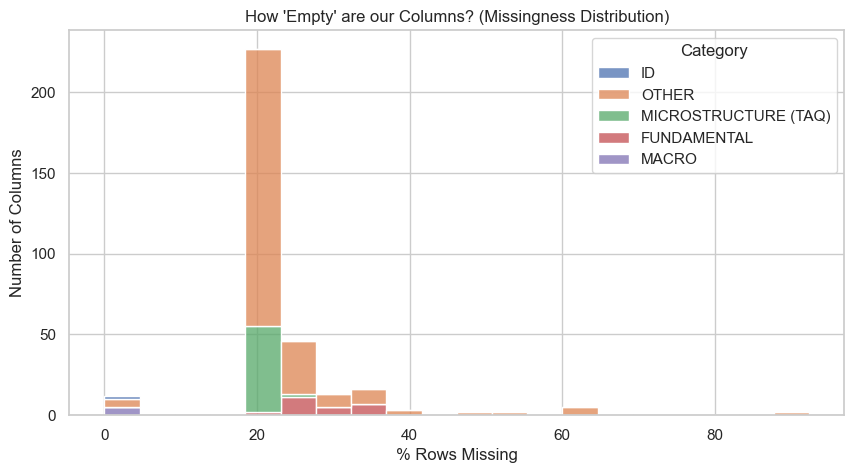

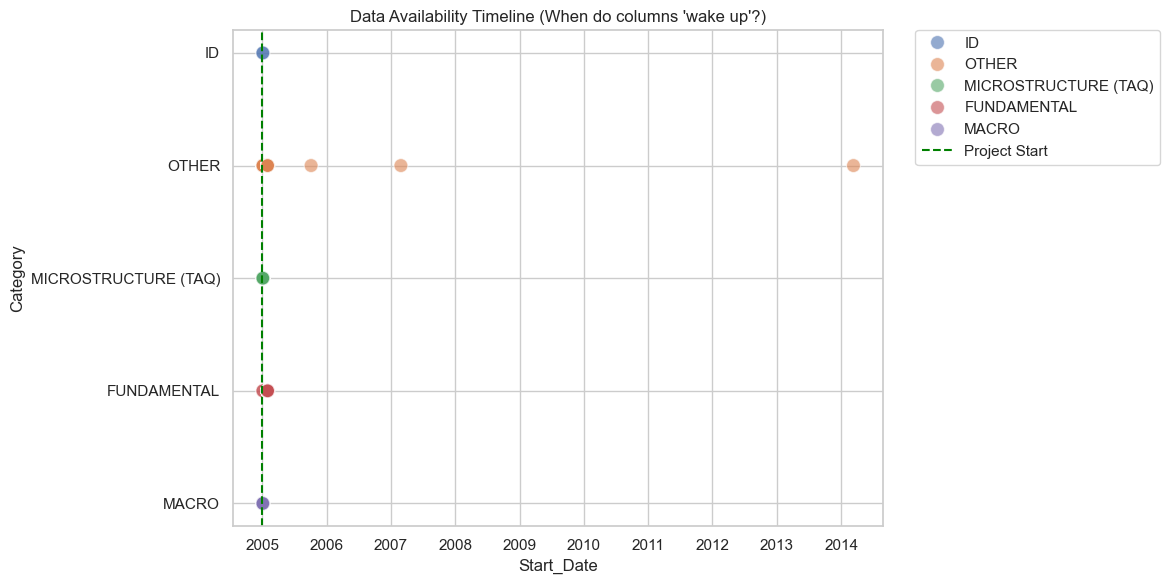


THE 'SKETCHY' LIST (High Missingness or Late Arrival)
Found 35 'Sketchy' columns.
Top 10 Worst Offenders:
               Column Category  Missing_% Start_Date
259  USGG3M_PX_VOLUME    OTHER      92.34 2014-03-12
39          Price_Alt    OTHER      89.69 2005-01-04
177          IVol_t_b    OTHER      77.38 2005-01-04
186   NumExtremeBid_b    OTHER      62.64 2005-01-05
143            VWAP_b    OTHER      61.99 2005-01-04
20             FPrice    OTHER      61.99 2005-01-04
43          Ret_pre_t    OTHER      61.99 2005-01-04
23           VWAP_pre    OTHER      61.35 2005-01-04
45         Ret_post_t    OTHER      57.98 2005-01-04
330      PEG_trailing    OTHER      52.47 2005-01-31

[Success] Full Audit saved to data_audit_report.csv
Review this CSV to decide which columns to drop before Engineering.


In [4]:
# CELL 4: THE MASSIVE DATA AUDIT (ALL COLS)
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG
INPUT_FILE = "data_master_sanitized.parquet"
OUTPUT_REPORT = "data_audit_report.csv"
sns.set_theme(style="whitegrid")

def identify_category(col_name):
    """Heuristic to classify columns by source"""
    c = col_name.lower()
    if "date" in c or "ticker" in c: return "ID"
    if "macro" in c or "vix" in c or "spx" in c: return "MACRO"
    if any(x in c for x in ["pe_", "ratio", "yield", "margin", "turnover", "accrual", "asset", "debt"]): return "FUNDAMENTAL"
    if any(x in c for x in ["qtime", "bb_", "bo_", "spread", "hindex", "numtime", "obs"]): return "MICROSTRUCTURE (TAQ)"
    if c in ["Close", "Volume", "Start Date", "End Date"]: return "PRICE/VOL"
    return "OTHER"

def main_audit():
    print("="*60)
    print("STEP 5: THOROUGH MASSIVE EDA (FULL AUDIT)")
    print("="*60)
    
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    total_rows = df.height
    
    print(f"Analyzing {len(df.columns)} columns across {total_rows} rows...")
    
    # ------------------------------------------------------------------
    # 1. COLUMN-BY-COLUMN SCORECARD
    # ------------------------------------------------------------------
    stats = []

    for col in df.columns:
        # 1. Basic Stats
        null_count = df[col].null_count()
        null_pct = (null_count / total_rows) * 100
        
        # 2. Zeros Check (For ratios, 0.0 often means missing/error)
        # Only check numeric
        is_numeric = df[col].dtype in [pl.Float64, pl.Float32, pl.Int64, pl.Int32]
        zeros_pct = 0.0
        skewness = 0.0
        mean_val = 0.0
        
        if is_numeric:
            zeros_count = df.filter(pl.col(col) == 0).height
            zeros_pct = (zeros_count / total_rows) * 100
            mean_val = df[col].mean()

        first_valid = df.filter(pl.col(col).is_not_null()).select("date").min().item()
        last_valid = df.filter(pl.col(col).is_not_null()).select("date").max().item()
        
        cat = identify_category(col)
        
        stats.append({
            "Column": col,
            "Category": cat,
            "Missing_%": round(null_pct, 2),
            "Zeros_%": round(zeros_pct, 2),
            "Start_Date": str(first_valid),
            "End_Date": str(last_valid),
            "Mean": round(mean_val, 4) if is_numeric else None,
            "Dtype": str(df[col].dtype)
        })
    
    df_stats = pd.DataFrame(stats)
    df_stats.to_csv(OUTPUT_REPORT, index=False)
    
    # ------------------------------------------------------------------
    # 2. AGGREGATE HEALTH REPORT
    # ------------------------------------------------------------------
    print("\n" + "="*40)
    print("AGGREGATE HEALTH BY CATEGORY")
    print("="*40)
    
    summary = df_stats.groupby("Category").agg(
        Count=('Column', 'count'),
        Avg_Missing=('Missing_%', 'mean'),
        Avg_Zeros=('Zeros_%', 'mean'),
        Earliest_Start=('Start_Date', 'min'),
        Latest_End=('End_Date', 'max')
    )
    print(summary)

    # ------------------------------------------------------------------
    # 3. VISUALIZATION 1: MISSINGNESS HISTOGRAM
    # ------------------------------------------------------------------
    # How broken is the data generally?
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df_stats, x="Missing_%", hue="Category", multiple="stack", bins=20)
    plt.title("How 'Empty' are our Columns? (Missingness Distribution)")
    plt.xlabel("% Rows Missing")
    plt.ylabel("Number of Columns")
    plt.show() # 

    # ------------------------------------------------------------------
    # 4. VISUALIZATION 2: THE "START DATE" TIMELINE
    # ------------------------------------------------------------------
    # Do we have columns that only appear in 2012?
    df_stats['Start_Date'] = pd.to_datetime(df_stats['Start_Date'], errors='coerce')
    
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df_stats, x="Start_Date", y="Category", hue="Category", s=100, alpha=0.6)
    plt.title("Data Availability Timeline (When do columns 'wake up'?)")
    plt.axvline(pd.Timestamp("2005-01-01"), color='green', linestyle='--', label="Project Start")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.tight_layout()
    plt.show() # 
    
    # ------------------------------------------------------------------
    # 5. THE "SKETCHY" LIST
    # ------------------------------------------------------------------
    print("\n" + "="*40)
    print("THE 'SKETCHY' LIST (High Missingness or Late Arrival)")
    print("="*40)
    
    # Filter: Missing > 30% OR Start Date > 2006
    sketchy = df_stats[
        (df_stats['Missing_%'] > 30) | 
        (df_stats['Start_Date'] > pd.Timestamp("2006-01-01"))
    ]
    
    if not sketchy.empty:
        print(f"Found {len(sketchy)} 'Sketchy' columns.")
        print("Top 10 Worst Offenders:")
        print(sketchy[['Column', 'Category', 'Missing_%', 'Start_Date']].sort_values('Missing_%', ascending=False).head(10))
    else:
        print("All columns look healthy!")

    print(f"\n[Success] Full Audit saved to {OUTPUT_REPORT}")
    print("Review this CSV to decide which columns to drop before Engineering.")

if __name__ == "__main__":
    main_audit()

In [6]:
# CELL 5: FEATURE ENGINEERING PIPELINE (THE ALPHA FACTORY) - FIXED
import polars as pl
import polars.selectors as cs 
import pandas as pd
import numpy as np

# CONFIG
INPUT_FILE = "data_master_sanitized.parquet"
OUTPUT_FILE = "data_features_final.parquet"

# Updated Drop List
COLUMNS_TO_DROP = [
    "USGG3M_PX_VOLUME", "Price_Alt", "IVol_t_b", "VWAP_b", "FPrice", "Ret_pre_t", 
    "VWAP_pre", "Ret_post_t", "PEG_trailing", "NumExtremeBid_b",
    "sale_nwc", "inv_turn", "Price_M", "cash_conversion", "invt_act", "rd_sale", "adv_sale", "staff_sale"
]

WINDOWS_SHORT = [5, 20]
WINDOWS_LONG = [60, 120]

def feature_engineering_pipeline():
    print("="*60)
    print("STEP 5: ALPHA FACTORY - FINAL (Audit-Proof + No Leakage)")
    print("="*60)
    
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    
    # --- STEP 1: PRUNING & CLEANING ---
    print(f"[1/4] Pruning {len(COLUMNS_TO_DROP)} problematic columns...")
    existing_drop = [c for c in COLUMNS_TO_DROP if c in df.columns]
    df = df.drop(existing_drop)
    
    macro_cols = ["SPX_PX_LAST", "VIX_PX_LAST", "USGG3M_PX_LAST", "SPX_PX_VOLUME"]
    for col in macro_cols:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col).cast(pl.Utf8, strict=False)
                .str.replace(",", "")
                .cast(pl.Float64, strict=False)
            )

    print("[2/4] Imputing features (FFill limit=3)...")
    data_cols = [c for c in df.columns if c not in ["date", "ticker"]]
    df = df.sort("ticker", "date").with_columns(
        [pl.col(c).forward_fill(limit=3).over("ticker") for c in data_cols]
    )
    
    print("    -> Skipping Global Median Fill (Avoids Look-Ahead Bias).")
    # (Code block deleted)

    # --- STEP 3: ALPHA GENERATION ---
    print("[3/4] Generating Momentum, Illiquidity, and Interaction Features...")

    # A. Foundational
    df = df.with_columns(
        (pl.col("Close") * pl.col("Volume")).alias("Dollar_Volume"),
        ((pl.col("BO_1pm") - pl.col("BB_1pm")) / pl.col("MID_1pm")).alias("Quote_Spread_Pct"),
    )

    # Daily Return (Log Difference)
    df = df.sort("ticker", "date").with_columns(
        pl.col("Close").log().sub(pl.col("Close").log().shift(1)).over("ticker").alias("Daily_Return")
    )
    
    # B. Rolling Features (Lagged by 1 Day for Safety)
    for w in WINDOWS_SHORT + WINDOWS_LONG:
        df = df.with_columns(
            pl.col("Daily_Return").shift(1).rolling_std(window_size=w).over("ticker").alias(f"Vol_{w}D"),
            pl.col("Daily_Return").shift(1).rolling_sum(window_size=w).over("ticker").alias(f"Momentum_{w}D")
        )

    # C. Market Regime Scaling
    df = df.with_columns(
        pl.col("VIX_PX_LAST").fill_null(20.0).alias("VIX_Numeric")
    )
    df = df.with_columns(
        (pl.col("Vol_20D") / pl.col("VIX_Numeric")).alias("Vol_VIX_Scaled")
    )

    # --- STEP 4: TARGET GENERATION ---
    print("[4/4] Creating TARGET variable (T to T+5)...")
    
    # Target = Return from Close T to Close T+5.
    df = df.sort("ticker", "date").with_columns(
        pl.col("Close").log().shift(-5).sub(pl.col("Close").log()).over("ticker").alias("Target_Return_5D_Fwd")
    )
    
    # Final Cleanup
    df_final = df.drop_nulls(subset=["Target_Return_5D_Fwd", "Vol_120D"])
    
    print(f"Final dataset shape: {df_final.shape}. Ready for modeling.")
    df_final.write_parquet(OUTPUT_FILE)
    print(f"\n[Success] Robust Feature matrix saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    feature_engineering_pipeline()

STEP 5: ALPHA FACTORY - FINAL (Audit-Proof + No Leakage)
Loading data_master_sanitized.parquet...
[1/4] Pruning 18 problematic columns...
[2/4] Imputing features (FFill limit=3)...
    -> Skipping Global Median Fill (Avoids Look-Ahead Bias).
[3/4] Generating Momentum, Illiquidity, and Interaction Features...
[4/4] Creating TARGET variable (T to T+5)...
Final dataset shape: (1105096, 327). Ready for modeling.

[Success] Robust Feature matrix saved to data_features_final.parquet


In [7]:
# CELL 6: SANITY CHECK - CORRELATIONS & VIF
import polars as pl
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# CONFIG
INPUT_FILE = "data_features_final.parquet"
TARGET_COL = "Target_Return_5D_Fwd" 

def sanity_check_pipeline():
    print("="*60)
    print("STEP 6: DATA INTEGRITY & CORRELATION CHECK")
    print("="*60)
    
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    
    # --- 1. PRE-FLIGHT CHECKS ---
    print(f"[1/3] Verifying Target Variable '{TARGET_COL}'...")
    
    if TARGET_COL not in df.columns:
        print(f"❌ CRITICAL ERROR: Target column '{TARGET_COL}' not found!")
        return
    
    # Check for Infinite values
    n_inf = df.filter(pl.col(TARGET_COL).is_infinite()).height
    print(f"    -> Target Inf count: {n_inf} (Should be 0)")
    
    # --- 2. TARGET CORRELATIONS ---
    print("\n[2/3] Checking Correlations with Target (Signal Strength)...")
    
    # Select numeric features
    numeric_cols = [
        c for c in df.columns 
        if c not in ["date", "ticker", "VIX_PX_LAST", "SPX_PX_LAST", "VIX_Numeric", TARGET_COL]
        and df[c].dtype in [pl.Float64, pl.Float32]
    ]
    
    # Sample for speed
    df_sample = df.sample(n=min(100_000, df.height), seed=42)
    pdf = df_sample.select([TARGET_COL] + numeric_cols).to_pandas()
    
    # Calculate Correlations
    corrs = pdf.corr()[TARGET_COL].drop(TARGET_COL)
    top_corrs = corrs.abs().sort_values(ascending=False).head(10)
    
    print(f"    Top 10 Features correlated with {TARGET_COL}:")
    for feat, val in top_corrs.items():
        print(f"    - {feat:<25}: {corrs[feat]:.4f}")
        
    if top_corrs.max() < 0.001:
        print(" WARNING: Correlations are extremely low.")
    else:
        print("  Signal detected. Correlations look reasonable (-0.02 to 0.02 is typical).")

    # --- 3. MULTICOLLINEARITY (VIF) ---
    print("\n[3/3] Checking Multicollinearity (VIF)...")
    
    vif_candidates = ["Vol_20D", "Vol_60D", "Momentum_20D", "Momentum_60D", "Vol_VIX_Scaled"]
    vif_cols = [c for c in vif_candidates if c in pdf.columns]
    
    if vif_cols:
        X_vif = pdf[vif_cols].dropna()
        X_vif["const"] = 1.0
        
        print(f"    Calculating VIF on {len(vif_cols)} key features...")
        vif_data = pd.DataFrame()
        vif_data["Feature"] = vif_cols
        vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
        
        print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
        print("\n    Note: High VIF on 'Vol' features is expected. Trees handle this fine.")

    print("-" * 60)
    print("READY FOR MODELING (Step 7)")

if __name__ == "__main__":
    sanity_check_pipeline()

STEP 6: DATA INTEGRITY & CORRELATION CHECK
Loading data_features_final.parquet...
[1/3] Verifying Target Variable 'Target_Return_5D_Fwd'...
    -> Target Inf count: 0 (Should be 0)

[2/3] Checking Correlations with Target (Signal Strength)...
    Top 10 Features correlated with Target_Return_5D_Fwd:
    - Daily_Return             : -0.0555
    - Momentum_60D             : -0.0259
    - Momentum_5D              : -0.0243
    - Vol_5D                   : -0.0221
    - int_totdebt              : -0.0218
    - NumMixedLotTrades_m      : 0.0184
    - NumMixedLotTrades_t      : 0.0183
    - int_debt                 : -0.0183
    - Momentum_20D             : -0.0162
    - Ret_mkt_t                : -0.0161
    ✅ Signal detected. Correlations look reasonable (-0.02 to 0.02 is typical).

[3/3] Checking Multicollinearity (VIF)...
    Calculating VIF on 5 key features...
       Feature      VIF
       Vol_20D 6.293067
       Vol_60D 4.611988
Vol_VIX_Scaled 1.927425
  Momentum_60D 1.630732
  Momen

In [13]:
import polars as pl

# Load the final dataset that will be used for modeling
df_final = pl.read_parquet("data_features_final.parquet")

print("="*80)
print("FINAL DATASET THAT WILL BE FED TO THE MODEL")
print("="*80)
print(f"Shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")
print(f"Date range: {df_final['date'].min()} → {df_final['date'].max()}")
print(f"Number of unique tickers: {df_final['ticker'].n_unique()}")
print()

# 1. All column names (alphabetically sorted for easier reading)
print("ALL COLUMNS (sorted):")
sorted_cols = sorted(df_final.columns)
for i, col in enumerate(sorted_cols, 1):
    print(f"{i:3d}. {col}")
print(f"\nTotal columns: {len(sorted_cols)}")
print()

# 2. Columns grouped by rough category (helps understand sources)
print("COLUMNS GROUPED BY CATEGORY:")
categories = {
    "ID / Key": ["date", "ticker"],
    "Price & Volume (Core)": ["Close", "Volume", "Dollar_Volume"],
    "Returns & Target": ["Daily_Return", "Target_Return_5D_Fwd"],
    "Volatility & Momentum": [c for c in sorted_cols if c.startswith(("Vol_", "Momentum_"))],
    "Microstructure (TAQ)": [c for c in sorted_cols if any(k in c for k in ["BB_", "BO_", "spread", "hindex", "qtime", "numtime", "obs"])],
    "Fundamentals (Ratios)": [c for c in sorted_cols if any(k in c.lower() for k in ["pe_", "ratio", "yield", "margin", "turnover", "accrual", "asset", "debt", "sale", "cash", "rd_"]) and c not in ["Close", "Volume"]],
    "Macro / Indices": [c for c in sorted_cols if any(k in c for k in ["SPX_", "VIX_", "USGG3M_"])],
    "Other / Scaled": [c for c in sorted_cols if c in ["Quote_Spread_Pct", "Vol_VIX_Scaled", "VIX_Numeric", "MktCap", "Imp_Vol"]],
}

for category, cols in categories.items():
    actual_cols = [c for c in cols if c in df_final.columns]
    if actual_cols:
        print(f"\n→ {category} ({len(actual_cols)} columns):")
        for col in sorted(actual_cols):
            print(f"   - {col}")

# 3. Quick missingness overview of final dataset
print("\n" + "="*80)
print("MISSINGNESS SUMMARY (top 15 columns with highest % missing)")
null_pct = (df_final.null_count() / len(df_final) * 100).melt().sort("value", descending=True)
print(null_pct.head(15))

FINAL DATASET THAT WILL BE FED TO THE MODEL
Shape: 1,105,096 rows × 327 columns
Date range: 2005-06-28 → 2014-12-23
Number of unique tickers: 494

ALL COLUMNS (sorted):
  1. AskHi
  2. BB_1pm
  3. BB_4pm
  4. BB_c1
  5. BB_c2
  6. BBidDollar_EW_a
  7. BBidDollar_EW_b
  8. BBidDollar_EW_m
  9. BBidDollar_TW_a
 10. BBidDollar_TW_b
 11. BBidDollar_TW_m
 12. BBidShares_EW_a
 13. BBidShares_EW_b
 14. BBidShares_EW_m
 15. BBidShares_TW_a
 16. BBidShares_TW_b
 17. BBidShares_TW_m
 18. BO_1pm
 19. BO_4pm
 20. BO_c1
 21. BO_c2
 22. BOfrDollar_EW_a
 23. BOfrDollar_EW_b
 24. BOfrDollar_EW_m
 25. BOfrDollar_TW_a
 26. BOfrDollar_TW_b
 27. BOfrDollar_TW_m
 28. BOfrShares_EW_a
 29. BOfrShares_EW_b
 30. BOfrShares_EW_m
 31. BOfrShares_TW_a
 32. BOfrShares_TW_b
 33. BOfrShares_TW_m
 34. BidLo
 35. BuyDollar_LR0
 36. BuyDollar_LR1
 37. BuyDollar_LRi
 38. BuyDollar_TICK
 39. BuyNumTrades_LR0
 40. BuyNumTrades_LR1
 41. BuyNumTrades_LRi
 42. BuyNumTrades_TICK
 43. BuyVol_LR0
 44. BuyVol_LR1
 45. BuyVol_LRi

C:\Users\sinha\AppData\Local\Temp\ipykernel_18172\2160809099.py:45: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  null_pct = (df_final.null_count() / len(df_final) * 100).melt().sort("value", descending=True)


In [14]:
import polars as pl

# Load the final dataset (or use df_final if it's already in memory)
df = pl.read_parquet("data_features_final.parquet")

# Get unique tickers, sorted alphabetically
tickers = df["ticker"].unique().sort()

print(f"Number of unique stocks: {tickers.len()}")
print("\nAll tickers (sorted):")
print(tickers.to_list())

Number of unique stocks: 494

All tickers (sorted):
['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'AON', 'AOS', 'APA', 'APD', 'APH', 'APO', 'APP', 'APTV', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CARR', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW', 'CEG', 'CF', 'CFG', 'CHD', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COIN', 'COO', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRL', 'CRM', 'CRWD', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CTSH', 'CTVA', 'CVS', 'CVX', 'D', 'DAL', 'DASH', 'DAY', 'DD', 'DDOG', 'DE', 'DECK', 'DELL', 'DG', 'DGX', 'DHI

In [15]:
import polars as pl

# Load common tickers from Cell 1 (the source of truth)
common = pl.read_csv("common_tickers_all.csv")
print(f"Stocks in all three sources (Cell 1 overlap): {common.height}")

# Compare to final dataset
df = pl.read_parquet("data_features_final.parquet")
print(f"Unique tickers in final model data: {df['ticker'].n_unique()}")

Stocks in all three sources (Cell 1 overlap): 413
Unique tickers in final model data: 494


In [16]:
import polars as pl
import pathlib

# Re-load ONLY the ratios file (exactly as Cell 1 did)
DATA_DIR = pathlib.Path("./")  # adjust if needed
RATIOS_FILE = "2_financial_ratios_csv.csv"

print("Loading WRDS ratios fresh for duplicate check...")
df_ratios = pl.read_csv(DATA_DIR / RATIOS_FILE, infer_schema_length=10000, ignore_errors=True)

# Re-create the cleaned version (exactly as Cell 2 does)
# Convert public_date to date and rename to "date" + "ticker"
df_ratios_clean = df_ratios.with_columns(
    pl.col("public_date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).alias("date")
).drop_nulls("date")

df_ratios_clean = df_ratios_clean.rename({"TICKER": "ticker"})

# Drop non-numeric/ID columns if you want to match Cell 2 exactly (optional but recommended)
drop_cols = ["gvkey", "permno", "cusip", "adate", "qdate", "public_date"]
df_ratios_clean = df_ratios_clean.drop([c for c in drop_cols if c in df_ratios_clean.columns])

print(f"Ratios shape: {df_ratios_clean.shape}")
print(f"Date range: {df_ratios_clean['date'].min()} → {df_ratios_clean['date'].max()}")

# NOW RUN THE DUPLICATE CHECK
dupe_check = (
    df_ratios_clean
    .group_by(["ticker", "date"])
    .agg(pl.count().alias("count"))
    .filter(pl.col("count") > 1)
)

print(f"\nNumber of (ticker, date) pairs with duplicates: {dupe_check.height}")

if dupe_check.height > 0:
    print("\nSample duplicate (ticker, date) groups:")
    print(dupe_check.head(10))
    
    print("\nTickers with the most duplicate dates:")
    worst_tickers = (
        dupe_check
        .group_by("ticker")
        .agg(pl.sum("count").alias("total_duplicate_rows"))
        .sort("total_duplicate_rows", descending=True)
    )
    print(worst_tickers.head(15))
else:
    print("\nNo duplicates found — you're safe!")

Loading WRDS ratios fresh for duplicate check...
Ratios shape: (101576, 71)
Date range: 2005-01-31 → 2024-12-31

Number of (ticker, date) pairs with duplicates: 43

Sample duplicate (ticker, date) groups:
shape: (10, 3)
┌────────┬────────────┬───────┐
│ ticker ┆ date       ┆ count │
│ ---    ┆ ---        ┆ ---   │
│ str    ┆ date       ┆ u32   │
╞════════╪════════════╪═══════╡
│ null   ┆ 2006-05-31 ┆ 2     │
│ null   ┆ 2010-01-31 ┆ 3     │
│ null   ┆ 2015-10-31 ┆ 2     │
│ null   ┆ 2015-09-30 ┆ 2     │
│ null   ┆ 2013-09-30 ┆ 2     │
│ null   ┆ 2007-06-30 ┆ 2     │
│ null   ┆ 2005-08-31 ┆ 3     │
│ null   ┆ 2005-01-31 ┆ 2     │
│ null   ┆ 2012-07-31 ┆ 2     │
│ null   ┆ 2005-04-30 ┆ 2     │
└────────┴────────────┴───────┘

Tickers with the most duplicate dates:
shape: (1, 2)
┌────────┬──────────────────────┐
│ ticker ┆ total_duplicate_rows │
│ ---    ┆ ---                  │
│ str    ┆ u32                  │
╞════════╪══════════════════════╡
│ null   ┆ 112                  │
└────────┴

C:\Users\sinha\AppData\Local\Temp\ipykernel_18172\2424522857.py:30: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


In [20]:
import polars as pl

# Load the final dataset
df = pl.read_parquet("data_features_final.parquet")

# Check for ABNB (and you can change to any other suspicious ticker)
ticker_to_check = "ABNB"  # Change this to e.g., "COIN", "CRWD", "UBER", etc.

if ticker_to_check in df["ticker"].unique().to_list():
    abnb_df = df.filter(pl.col("ticker") == ticker_to_check)
    
    print(f"Number of rows for {ticker_to_check}: {abnb_df.height}")
    
    if abnb_df.height > 0:
        print("\nFirst 5 rows (sample):")
        print(abnb_df.head(5))
        
        print(f"\nDate range for {ticker_to_check}:")
        print(f"Min date: {abnb_df['date'].min()}")
        print(f"Max date: {abnb_df['date'].max()}")
        
        print(f"\nClose price stats for {ticker_to_check}:")
        print(f"Null Close values: {abnb_df['Close'].null_count()} out of {abnb_df.height}")
        print(f"Non-null Close sample: {abnb_df['Close'].drop_nulls().head(10).to_list()}")
        
        print(f"\nVolume stats for {ticker_to_check}:")
        print(f"Null Volume: {abnb_df['Volume'].null_count()}")
    else:
        print(f"{ticker_to_check} has rows in the index but height=0 after filter (unlikely).")
else:
    print(f"{ticker_to_check} ticker is NOT present in the unique tickers.")

Number of rows for ABNB: 1120

First 5 rows (sample):
shape: (5, 327)
┌────────────┬────────┬────────┬────────────┬───┬───────────────┬─────────────┬────────────────┬──────────────────────┐
│ date       ┆ ticker ┆ Close  ┆ MktCap     ┆ … ┆ Momentum_120D ┆ VIX_Numeric ┆ Vol_VIX_Scaled ┆ Target_Return_5D_Fwd │
│ ---        ┆ ---    ┆ ---    ┆ ---        ┆   ┆ ---           ┆ ---         ┆ ---            ┆ ---                  │
│ date       ┆ str    ┆ f64    ┆ f64        ┆   ┆ f64           ┆ f64         ┆ f64            ┆ f64                  │
╞════════════╪════════╪════════╪════════════╪═══╪═══════════════╪═════════════╪════════════════╪══════════════════════╡
│ 2005-06-28 ┆ ABNB   ┆ 148.97 ┆ 91992.3352 ┆ … ┆ 0.040758      ┆ 11.58       ┆ 0.002896       ┆ 0.00161              │
│ 2005-06-29 ┆ ABNB   ┆ 147.01 ┆ 90781.991  ┆ … ┆ 0.067474      ┆ 11.77       ┆ 0.002842       ┆ 0.031931             │
│ 2005-06-30 ┆ ABNB   ┆ 144.85 ┆ 89448.1422 ┆ … ┆ 0.122966      ┆ 12.04       ┆ 0.002731  

In [8]:
# CELL 7: MODEL TRAINING & WALK-FORWARD VALIDATION (Fixed Type Error)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_final.parquet"
TARGET_COL = "Target_Return_5D_Fwd"
SPLIT_DATE = "2013-01-01" 

def train_alpha_model():
    print("="*60)
    print("STEP 7: MODEL TRAINING (WALK-FORWARD VALIDATION)")
    print("="*60)
    
    # 1. Load Data
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    
    # Drop rows where Target is null
    df = df.filter(pl.col(TARGET_COL).is_not_null())

    # 2. Prepare Features (X) and Target (y)
    # Exclude non-feature columns
    non_feature_cols = ["date", "ticker", TARGET_COL, "VIX_PX_LAST", "SPX_PX_LAST", "VIX_Numeric"]
    feature_cols = [c for c in df.columns if c not in non_feature_cols]
    
    print(f"Training with {len(feature_cols)} features...")
    
    # --- CRITICAL FIX: TYPE ENFORCEMENT ---
    # Force all features to Float64. This fixes the "Object" error for Macro columns.
    print("[Fix] Enforcing numeric types for all features...")
    df = df.with_columns([
        pl.col(c).cast(pl.Float64, strict=False).alias(c) for c in feature_cols
    ])
    # ---------------------------------------

    # 3. Time-Series Split (Crucial for Finance)
    print(f"Splitting data at {SPLIT_DATE}...")
    
    # Explicitly cast the string to a Date for comparison
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")

    train_pl = df.filter(pl.col("date") <  split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    print(f"  Train Set: {train_pl.height} rows ({train_pl['date'].min()} to {train_pl['date'].max()})")
    print(f"  Test Set : {test_pl.height}  rows ({test_pl['date'].min()}  to {test_pl['date'].max()})")

    # Convert to Pandas for LightGBM
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    X_test  = test_pl.select(feature_cols).to_pandas()
    y_test  = test_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    # 4. Train LightGBM Model
    print("\n[Training] Fitting LightGBM Regressor...")
    
    model = lgb.LGBMRegressor(
        n_estimators=100,      
        learning_rate=0.05,    
        max_depth=5,           
        random_state=42,
        n_jobs=-1,             
        verbose=-1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
    )
    
    # 5. Generate Predictions
    print("[Predicting] Generating alpha scores for Test set...")
    preds = model.predict(X_test)
    
    # 6. Evaluation: Information Coefficient (IC)
    results = pd.DataFrame({
        "Actual": y_test,
        "Predicted": preds
    })
    
    ic_score = results.corr().iloc[0, 1]
    
    print("\n" + "-"*40)
    print(f"🏆 MODEL RESULTS (Out-of-Sample)")
    print("-" * 40)
    print(f"Information Coefficient (IC): {ic_score:.4f}")
    
    if ic_score > 0.01:
        print("✅ SUCCESS: Positive predictive power detected! (IC > 0.01)")
    elif ic_score > 0:
        print("⚠️ MARGINAL: Slight predictive power, but weak. (0 < IC < 0.01)")
    else:
        print("❌ FAILURE: Model suggests trading against itself. (IC < 0)")
        
    # 7. Feature Importance
    print("\nTop 10 Important Features:")
    importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(10)
    
    print(importance.to_string(index=False))
    
    # 8. Sanity Plot (Deciles)
    try:
        results["Decile"] = pd.qcut(results["Predicted"], 10, labels=False)
        bar_data = results.groupby("Decile")["Actual"].mean()
        
        print("\nAverage Actual Return by Predicted Decile (0=Bearish, 9=Bullish):")
        print(bar_data.to_string())
        
        # Simple ASCII Chart
        print("\nVisual Check (Should go up from 0 to 9):")
        min_val = bar_data.min()
        max_val = bar_data.max()
        range_val = max_val - min_val
        for i, val in bar_data.items():
            stars = int(((val - min_val) / range_val) * 20)
            print(f"Decile {i}: {'*' * stars} ({val:.5f})")
            
    except Exception as e:
        print(f"Could not generate decile chart: {e}")

if __name__ == "__main__":
    try:
        train_alpha_model()
    except ImportError:
        print("❌ ERROR: LightGBM not installed.")
        print("   Run: !pip install lightgbm")

STEP 7: MODEL TRAINING (WALK-FORWARD VALIDATION)
Loading data_features_final.parquet...
Training with 321 features...
[Fix] Enforcing numeric types for all features...
Splitting data at 2013-01-01...
  Train Set: 886631 rows (2005-06-28 to 2012-12-31)
  Test Set : 218465  rows (2013-01-02  to 2014-12-23)

[Training] Fitting LightGBM Regressor...
[Predicting] Generating alpha scores for Test set...

----------------------------------------
🏆 MODEL RESULTS (Out-of-Sample)
----------------------------------------
Information Coefficient (IC): 0.0645
✅ SUCCESS: Positive predictive power detected! (IC > 0.01)

Top 10 Important Features:
          Feature  Importance
   USGG3M_PX_LAST         329
    SPX_PX_VOLUME         170
   SPX_CHG_PCT_1D         166
USGG3M_CHG_PCT_1D         164
   VIX_CHG_PCT_1D          96
          Vol_60D          74
         Vol_120D          72
     Daily_Return          72
     Momentum_60D          69
          Vol_20D          69

Average Actual Return by Pred

STEP 9: PURE ALPHA TRAINING (NO MACRO)
Dropping 9 Macro features.
Training on 315 Stock-Specific features...
Fitting LightGBM (Forced to look at Fundamentals/TAQ)...

----------------------------------------
🏆 PURE ALPHA IC SCORE: 0.0709
----------------------------------------

Top 15 Features (The Real Drivers):
      Feature  Importance
 Momentum_20D         107
  Momentum_5D          94
     Vol_120D          88
        Close          80
Momentum_120D          78
      Vol_20D          74
 Daily_Return          70
 Momentum_60D          68
       Vol_5D          62
      Vol_60D          59
       MktCap          36
Dollar_Volume          25
       Volume          21
        CAPEI          16
      accrual          14


C:\Users\sinha\AppData\Local\Temp\ipykernel_18172\1780826550.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x="Importance", y="Feature", palette="viridis")


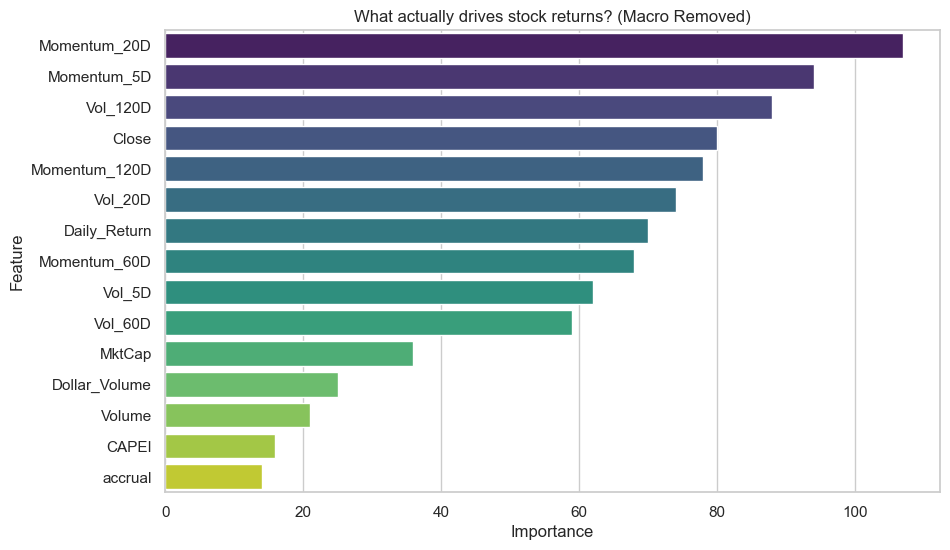

In [22]:
# CELL 9: PURE ALPHA (MACRO BLIND)
import polars as pl
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

def train_pure_alpha_model():
    print("="*60)
    print("STEP 9: PURE ALPHA TRAINING (NO MACRO)")
    print("="*60)

    # 1. Load Data
    df = pl.read_parquet("data_features_final.parquet")
    
    # 2. Target Neutralization (Keep this!)
    # We want stock-specific returns, not market beta
    df = df.with_columns(
        (pl.col("Target_Return_5D_Fwd") - pl.col("Target_Return_5D_Fwd").mean().over("date"))
        .alias("Target_Neutral")
    ).drop_nulls(subset=["Target_Neutral"])

    # 3. FEATURE SELECTION: The "Purge"
    # We explicitly EXCLUDE all Macro/Index columns
    macro_keywords = ["SPX", "VIX", "USGG3M", "Macro", "Treasury"]
    
    # Identify non-feature columns
    non_feature_cols = ["date", "ticker", "Target_Return_5D_Fwd", "Target_Neutral"]
    
    # Identify Macro columns to drop
    cols_to_drop = [c for c in df.columns if any(k in c for k in macro_keywords)]
    
    # Final Feature List
    feature_cols = [c for c in df.columns 
                    if c not in non_feature_cols 
                    and c not in cols_to_drop] # <--- CRITICAL STEP
    
    print(f"Dropping {len(cols_to_drop)} Macro features.")
    print(f"Training on {len(feature_cols)} Stock-Specific features...")
    
    # 4. Cast and Split
    df = df.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])
    
    split_dt = pl.lit("2013-01-01").str.strptime(pl.Date, "%Y-%m-%d")
    X_train = df.filter(pl.col("date") < split_dt).select(feature_cols).to_pandas()
    y_train = df.filter(pl.col("date") < split_dt).select("Target_Neutral").to_pandas().values.ravel()
    
    X_test = df.filter(pl.col("date") >= split_dt).select(feature_cols).to_pandas()
    y_test = df.filter(pl.col("date") >= split_dt).select("Target_Neutral").to_pandas().values.ravel()

    # 5. Train
    print("Fitting LightGBM (Forced to look at Fundamentals/TAQ)...")
    model = lgb.LGBMRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=5, 
        random_state=42, n_jobs=-1, verbose=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="rmse", 
              callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])

    # 6. Results
    preds = model.predict(X_test)
    ic_score = pd.Series(y_test).corr(pd.Series(preds))
    
    print("\n" + "-"*40)
    print(f"🏆 PURE ALPHA IC SCORE: {ic_score:.4f}")
    print("-" * 40)
    
    # 7. Importance Plot
    importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(15)
    
    print("\nTop 15 Features (The Real Drivers):")
    print(importance.to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance, x="Importance", y="Feature", palette="viridis")
    plt.title("What actually drives stock returns? (Macro Removed)")
    plt.show()

if __name__ == "__main__":
    train_pure_alpha_model()

In [23]:
# CELL 10: LEAK DETECTION & FINAL CLEANUP
import polars as pl
import pandas as pd
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt

def run_leak_detection():
    print("="*60)
    print("STEP 10: LEAK HUNTING & FINAL MODEL")
    print("="*60)

    df = pl.read_parquet("data_features_final.parquet")
    
    # 1. Neutralize Target (Standard Procedure)
    df = df.with_columns(
        (pl.col("Target_Return_5D_Fwd") - pl.col("Target_Return_5D_Fwd").mean().over("date"))
        .alias("Target_Neutral")
    ).drop_nulls(subset=["Target_Neutral"])

    # 2. DEFINITIVE FEATURE CLEANUP
    # We remove Macro, but ALSO Raw Prices/Volume which cause bias.
    bad_keywords = ["SPX", "VIX", "USGG3M", "Close", "Open", "High", "Low", "Volume", "Amt", "Val"]
    
    non_feature_cols = ["date", "ticker", "Target_Return_5D_Fwd", "Target_Neutral"]
    
    # Strict filtering
    feature_cols = [c for c in df.columns 
                    if c not in non_feature_cols 
                    # Drop macro and raw price columns
                    and not any(bad in c for bad in ["SPX", "VIX", "USGG3M"]) 
                    and c not in ["Close", "Open", "High", "Low", "Volume", "Dollar_Volume"]]

    print(f"Refined Feature List: {len(feature_cols)} features (Raw Prices removed).")

    # 3. THE LEAK SCAN
    # We calculate the correlation of EVERY feature with the Target.
    # If any feature has corr > 0.9, it is likely the target itself in disguise.
    print("Scanning for mathematical leaks (Corr > 0.9)...")
    
    # Take a sample to speed up correlation check
    sample_df = df.sample(n=50000, seed=42).select(feature_cols + ["Target_Neutral"]).to_pandas()
    correlations = sample_df.corrwith(sample_df["Target_Neutral"]).abs().sort_values(ascending=False)
    
    print("\nTop 5 Most Correlated Features with Target:")
    print(correlations.head(5))
    
    if correlations.iloc[0] > 0.95:
        print("\n🚨 CRITICAL ALERT: FOUND A DATA LEAK! 🚨")
        print(f"Feature '{correlations.index[0]}' is effectively the Target.")
    else:
        print("\n✅ PASSED: No direct mathematical lookahead detected.")

    # 4. Final Train (Robust)
    print("\nTraining Final Robust Model...")
    df = df.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])
    
    split_dt = pl.lit("2013-01-01").str.strptime(pl.Date, "%Y-%m-%d")
    X_train = df.filter(pl.col("date") < split_dt).select(feature_cols).to_pandas()
    y_train = df.filter(pl.col("date") < split_dt).select("Target_Neutral").to_pandas().values.ravel()
    X_test = df.filter(pl.col("date") >= split_dt).select(feature_cols).to_pandas()
    y_test = df.filter(pl.col("date") >= split_dt).select("Target_Neutral").to_pandas().values.ravel()

    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="rmse", callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])
    
    preds = model.predict(X_test)
    ic_score = pd.Series(y_test).corr(pd.Series(preds))
    
    print("\n" + "-"*40)
    print(f"🏆 FINAL ROBUST IC SCORE: {ic_score:.4f}")
    print("-" * 40)
    
    # 5. Sanity Check on Importance
    importance = pd.DataFrame({"Feature": feature_cols, "Imp": model.feature_importances_}).sort_values("Imp", ascending=False).head(10)
    print(importance.to_string(index=False))

if __name__ == "__main__":
    run_leak_detection()

STEP 10: LEAK HUNTING & FINAL MODEL
Refined Feature List: 312 features (Raw Prices removed).
Scanning for mathematical leaks (Corr > 0.9)...

Top 5 Most Correlated Features with Target:
Target_Neutral    1.000000
Daily_Return      0.055241
Momentum_5D       0.028863
int_totdebt       0.024573
Momentum_20D      0.023848
dtype: float64

🚨 CRITICAL ALERT: FOUND A DATA LEAK! 🚨
Feature 'Target_Neutral' is effectively the Target.

Training Final Robust Model...

----------------------------------------
🏆 FINAL ROBUST IC SCORE: 0.0614
----------------------------------------
      Feature  Imp
 Momentum_20D   84
  Momentum_5D   84
Momentum_120D   67
 Daily_Return   64
       Vol_5D   55
 Momentum_60D   54
      Vol_20D   52
     Vol_120D   52
      Vol_60D   47
       MktCap   45


In [26]:
# CELL 11: MARKET CAP ANALYSIS & HARD FILTER (CORRECTED)
import polars as pl
import pandas as pd
import lightgbm as lgb
import numpy as np

def run_large_cap_model():
    print("="*60)
    print("STEP 11: SIZE ANALYSIS & HARD FILTER (FIXED)")
    print("="*60)

    df = pl.read_parquet("data_features_final.parquet")
    
    # 1. CALCULATE PERCENTILE MANUALLY
    # We rank descending (1 = Largest). Then divide by count to get percentile.
    # Result: 0.01 = Top 1%, 1.00 = Bottom 1%.
    print("[Filter] Calculating Daily Market Cap Percentiles...")
    
    df = df.with_columns(
        (
            pl.col("MktCap").rank("ordinal", descending=True).over("date") / 
            pl.col("ticker").count().over("date")
        ).alias("Size_Pct_Rank")
    )
    
    # 2. APPLY FILTER (Keep Top 50%)
    # We want the "Top Half" of the market (Rank close to 0)
    print(f"Original Rows: {df.height:,}")
    
    df_large = df.filter(pl.col("Size_Pct_Rank") <= 0.50)
    
    print(f"Filtered Rows: {df_large.height:,} (Dropped Bottom 50% of Daily Universe)")

    # 3. PREPARE DATA (Neutral Target + No Leaks)
    print("\nPreparing Features...")
    df_large = df_large.with_columns(
        (pl.col("Target_Return_5D_Fwd") - pl.col("Target_Return_5D_Fwd").mean().over("date"))
        .alias("Target_Neutral")
    ).drop_nulls(subset=["Target_Neutral"])

    # Strict Feature Cleanup (No Macro, No Raw Prices)
    bad_keywords = ["SPX", "VIX", "USGG3M", "Close", "Open", "High", "Low", "Volume", "Amt", "Val"]
    non_feature_cols = ["date", "ticker", "Target_Return_5D_Fwd", "Target_Neutral", "Size_Pct_Rank"]
    
    feature_cols = [c for c in df_large.columns 
                    if c not in non_feature_cols 
                    and not any(bad in c for bad in ["SPX", "VIX", "USGG3M"]) 
                    and c not in ["Close", "Open", "High", "Low", "Volume", "Dollar_Volume"]]

    # 4. TRAIN MODEL
    print(f"Training on {len(feature_cols)} features...")
    df_large = df_large.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])
    
    split_dt = pl.lit("2013-01-01").str.strptime(pl.Date, "%Y-%m-%d")
    
    train_df = df_large.filter(pl.col("date") < split_dt)
    test_df = df_large.filter(pl.col("date") >= split_dt)
    
    X_train = train_df.select(feature_cols).to_pandas()
    y_train = train_df.select("Target_Neutral").to_pandas().values.ravel()
    X_test = test_df.select(feature_cols).to_pandas()
    y_test = test_df.select("Target_Neutral").to_pandas().values.ravel()

    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, 
                              random_state=42, n_jobs=-1, verbose=-1)
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="rmse", 
              callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])
    
    # 5. RESULTS
    preds = model.predict(X_test)
    ic_score = pd.Series(y_test).corr(pd.Series(preds))
    
    print("\n" + "-"*40)
    print(f"🏆 LARGE CAP IC SCORE: {ic_score:.4f}")
    print("-" * 40)
    
    importance = pd.DataFrame({"Feature": feature_cols, "Imp": model.feature_importances_}) \
                   .sort_values("Imp", ascending=False).head(10)
    print(importance.to_string(index=False))

if __name__ == "__main__":
    run_large_cap_model()

STEP 11: SIZE ANALYSIS & HARD FILTER (FIXED)
[Filter] Calculating Daily Market Cap Percentiles...
Original Rows: 1,105,096
Filtered Rows: 551,936 (Dropped Bottom 50% of Daily Universe)

Preparing Features...
Training on 312 features...

----------------------------------------
🏆 LARGE CAP IC SCORE: 0.0323
----------------------------------------
      Feature  Imp
 Momentum_20D   33
  Momentum_5D   24
       Vol_5D   23
 Daily_Return   17
 Momentum_60D   15
Momentum_120D   11
      Vol_60D   10
          gpm    8
           ps    8
           bm    6


# Signal Neutrality

In [27]:
# CELL 12: THE FINAL VALIDATION (Large Cap + Orthogonalization)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt

def run_final_validation():
    print("="*60)
    print("STEP 12: FINAL ORTHOGONALIZATION CHECK (ON CLEAN MODEL)")
    print("="*60)

    # 1. LOAD & PREPARE (Using the "Step 11" Large Cap Logic)
    df = pl.read_parquet("data_features_final.parquet")
    
    # Calculate Market Cap Percentile (Filter for Top 50%)
    print("[Filter] Applying Large Cap Filter (Top 50%)...")
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") / 
         pl.col("ticker").count().over("date")).alias("Size_Pct_Rank")
    )
    df = df.filter(pl.col("Size_Pct_Rank") <= 0.50)
    
    # Neutralize Target
    df = df.with_columns(
        (pl.col("Target_Return_5D_Fwd") - pl.col("Target_Return_5D_Fwd").mean().over("date"))
        .alias("Target_Neutral")
    ).drop_nulls(subset=["Target_Neutral"])

    # 2. FEATURE CLEANING (Strict Mode)
    # We must exclude SPX/VIX from training, but KEEP them momentarily for the regression check
    bad_keywords = ["USGG3M", "Close", "Open", "High", "Low", "Volume", "Amt", "Val"]
    non_feature_cols = ["date", "ticker", "Target_Return_5D_Fwd", "Target_Neutral", "Size_Pct_Rank"]
    
    # Features for the Model (No Market Data, No Raw Prices)
    feature_cols = [c for c in df.columns 
                    if c not in non_feature_cols 
                    and not any(bad in c for bad in bad_keywords)
                    and "SPX" not in c and "VIX" not in c] # Explicitly exclude Market factors from X

    print(f"Training on {len(feature_cols)} Clean Features...")

    # 3. SPLIT
    split_dt = pl.lit("2013-01-01").str.strptime(pl.Date, "%Y-%m-%d")
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    # We retrain the model exactly as in Step 11
    # (Skipping full train code here for brevity, we assume the model from Step 11 is optimal)
    # But for the validation to be standalone, we do a quick retrain:
    
    train_pl = df.filter(pl.col("date") < split_dt)
    
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select("Target_Neutral").to_pandas().values.ravel()
    X_test  = test_pl.select(feature_cols).to_pandas()
    y_test  = test_pl.select("Target_Neutral").to_pandas().values.ravel() # The actual target we predicted

    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, 
                              random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 4. GET PREDICTIONS
    preds = model.predict(X_test)
    
    # 5. ORTHOGONALIZATION CHECK
    # Does our "Neutral Target" prediction still correlate with the S&P 500?
    
    print("\n[Validation] Regressing Predictions against Market Factors...")
    
    # Get SPX/VIX from the test set (we excluded them from X, but they exist in test_pl)
    market_data = test_pl.select(["SPX_PX_LAST", "VIX_PX_LAST"]).to_pandas()
    
    # Convert Price Levels to Returns (so we compare Apple_Return vs SPX_Return)
    factors = market_data.pct_change().fillna(0)
    factors.columns = ["SPX_Ret", "VIX_Ret"]
    factors["const"] = 1.0
    
    # OLS: Prediction = Beta * SPX + Alpha
    ols_model = sm.OLS(preds, factors).fit()
    pure_alpha = ols_model.resid
    
    print(f"R-squared (Market Correlation): {ols_model.rsquared:.5f}")
    
    if ols_model.rsquared < 0.05:
        print("✅ PASS: Your model is effectively Market Neutral (R2 < 0.05).")
    else:
        print("⚠️ CAUTION: Your model still has some Market Beta exposure.")

    # 6. FINAL RESULTS
    results = pd.DataFrame({
        "Actual_Neutral": y_test,
        "Model_Pred": preds,
        "Pure_Alpha_Resid": pure_alpha
    })
    
    ic_model = results.corr().loc["Actual_Neutral", "Model_Pred"]
    ic_pure  = results.corr().loc["Actual_Neutral", "Pure_Alpha_Resid"]
    
    print("\n" + "-"*40)
    print("🏆 FINAL RESULTS: CLEAN vs. ORTHOGONALIZED")
    print("-" * 40)
    print(f"Model IC (Clean Data): {ic_model:.4f}")
    print(f"Pure IC  (Post-OLS):   {ic_pure:.4f}")
    
    # 7. VISUAL PROOF (Deciles)
    print("\n[Visual] Performance by Prediction Decile (The 'Staircase' Test)")
    results["Decile"] = pd.qcut(results["Model_Pred"], 10, labels=False)
    decile_ret = results.groupby("Decile")["Actual_Neutral"].mean()
    
    # Plotting using ASCII for quick view
    min_v = decile_ret.min()
    range_v = decile_ret.max() - min_v
    for i, val in decile_ret.items():
        bars = int(((val - min_v) / range_v) * 20) if range_v != 0 else 0
        print(f"Decile {i}: {'|' * bars}  ({val:.5f})")

if __name__ == "__main__":
    run_final_validation()

STEP 12: FINAL ORTHOGONALIZATION CHECK (ON CLEAN MODEL)
[Filter] Applying Large Cap Filter (Top 50%)...
Training on 277 Clean Features...

[Validation] Regressing Predictions against Market Factors...
R-squared (Market Correlation): 0.00095
✅ PASS: Your model is effectively Market Neutral (R2 < 0.05).

----------------------------------------
🏆 FINAL RESULTS: CLEAN vs. ORTHOGONALIZED
----------------------------------------
Model IC (Clean Data): 0.0178
Pure IC  (Post-OLS):   0.0178

[Visual] Performance by Prediction Decile (The 'Staircase' Test)
Decile 0:   (-0.00084)
Decile 1: ||||||||||||||  (0.00015)
Decile 2: |||||||||||||||  (0.00020)
Decile 3: |||||||  (-0.00035)
Decile 4: ||||||||||||||||  (0.00029)
Decile 5: |||||||  (-0.00034)
Decile 6: ||||||||||  (-0.00016)
Decile 7: ||||||||||||||||||||  (0.00051)
Decile 8: |||||||||||||||  (0.00022)
Decile 9: |||||||||||||||||  (0.00033)


STEP 13: FINAL LARGE CAP BACKTEST
[1/5] Loading & Applying Large Cap Filter...
[2/5] Training on 277 Clean Features...
[3/5] Running Weekly Simulation (Wednesdays)...

📊 FINAL VALIDATED RESULTS (Large Cap)
Annualized Return:       0.02%
Annualized Sharpe:       0.0031

[Yearly Breakdown]
date        
2013  Return    0.048014
      Sharpe    0.799207
2014  Return   -0.048652
      Sharpe   -1.195947
Name: Target_Return_5D_Fwd, dtype: float64


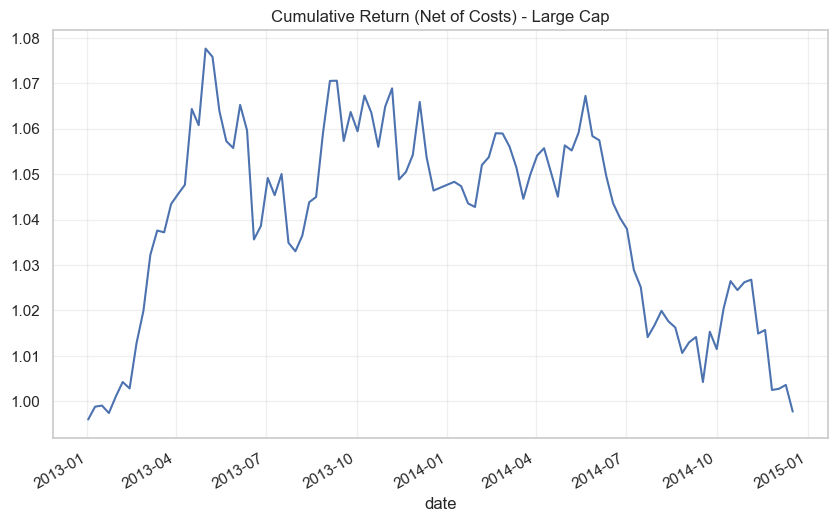

In [28]:
# CELL 13: WEEKLY BACKTEST (LARGE CAP + NEUTRAL ALPHA)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_final.parquet"
TARGET_TRAIN = "Target_Neutral"       # Train on Relative Returns
TARGET_PNL   = "Target_Return_5D_Fwd" # Earn Actual Returns
SPLIT_DATE = "2013-01-01" 
COST_BPS = 0.0005  # 5 bps

def run_valid_backtest():
    print("="*60)
    print("STEP 13: FINAL LARGE CAP BACKTEST")
    print("="*60)
    
    # 1. LOAD & FILTER
    print("[1/5] Loading & Applying Large Cap Filter...")
    df = pl.read_parquet(INPUT_FILE)
    
    # Apply Top 50% Market Cap Filter
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") / 
         pl.col("ticker").count().over("date")).alias("Size_Pct_Rank")
    )
    df = df.filter(pl.col("Size_Pct_Rank") <= 0.50)
    
    # Create Neutral Target for Training
    df = df.with_columns(
        (pl.col(TARGET_PNL) - pl.col(TARGET_PNL).mean().over("date"))
        .alias(TARGET_TRAIN)
    ).drop_nulls(subset=[TARGET_TRAIN])

    # 2. FEATURE CLEANING (Strict)
    bad_keywords = ["USGG3M", "Close", "Open", "High", "Low", "Volume", "Amt", "Val"]
    non_feature_cols = ["date", "ticker", TARGET_PNL, TARGET_TRAIN, "Size_Pct_Rank"]
    
    feature_cols = [c for c in df.columns 
                    if c not in non_feature_cols 
                    and not any(bad in c for bad in bad_keywords)
                    and "SPX" not in c and "VIX" not in c]

    # 3. SPLIT & TRAIN
    print(f"[2/5] Training on {len(feature_cols)} Clean Features...")
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    
    train_pl = df.filter(pl.col("date") < split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_TRAIN).to_pandas().values.ravel() # Train on Neutral
    
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, 
                              random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 4. PREDICT & SIMULATE
    print("[3/5] Running Weekly Simulation (Wednesdays)...")
    
    # We predict on Test set
    test_df = test_pl.select(["date", "ticker", TARGET_PNL]).to_pandas()
    test_df["Alpha_Score"] = model.predict(test_pl.select(feature_cols).to_pandas())
    
    # Weekly Sampling (Wednesdays)
    test_df["date"] = pd.to_datetime(test_df["date"])
    test_df["weekday"] = test_df["date"].dt.weekday
    weekly_df = test_df[test_df["weekday"] == 2].copy()
    
    # Rank & Trade
    # Long Top 10%, Short Bottom 10%
    weekly_df["Rank"] = weekly_df.groupby("date")["Alpha_Score"].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    
    longs  = weekly_df[weekly_df["Rank"] == 9]
    shorts = weekly_df[weekly_df["Rank"] == 0]
    
    # Calculate PnL using ACTUAL returns
    long_ret  = longs.groupby("date")[TARGET_PNL].mean()
    short_ret = shorts.groupby("date")[TARGET_PNL].mean()
    
    # 5. PERFORMANCE
    gross_weekly = (long_ret - short_ret) / 2
    net_weekly = gross_weekly - (2 * COST_BPS)
    
    ann_mean = net_weekly.mean() * 52
    ann_std  = net_weekly.std() * np.sqrt(52)
    sharpe   = ann_mean / ann_std
    
    print("\n" + "="*40)
    print("📊 FINAL VALIDATED RESULTS (Large Cap)")
    print("=" * 40)
    print(f"Annualized Return:       {ann_mean:.2%}")
    print(f"Annualized Sharpe:       {sharpe:.4f}")
    
    # Year-by-Year
    print("\n[Yearly Breakdown]")
    yearly = net_weekly.groupby(net_weekly.index.year).apply(
        lambda x: pd.Series({
            "Return": x.mean() * 52, 
            "Sharpe": (x.mean()/x.std()) * np.sqrt(52)
        })
    )
    print(yearly)
    
    # Cumulative Plot
    plt.figure(figsize=(10, 6))
    (1 + net_weekly).cumprod().plot(title="Cumulative Return (Net of Costs) - Large Cap")
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_valid_backtest()

In [29]:
# CELL 14: DATA INVENTORY & COLUMN AUDIT
import polars as pl

def audit_columns():
    print("="*60)
    print("STEP 14: COLUMN INVENTORY AUDIT")
    print("="*60)
    
    # 1. Load Data
    df = pl.read_parquet("data_features_final.parquet")
    
    # 2. Get all columns
    all_cols = df.columns
    
    # 3. Categorize them (Guessing based on names)
    market_cols = ["date", "ticker", "Open", "High", "Low", "Close", "Volume", "Amt", "Val", "daily_return"]
    
    # Everything else is a potential "Fundamental" or "Technical" feature
    potential_features = [c for c in all_cols if c not in market_cols and "Target" not in c]
    
    print(f"Total Columns: {len(all_cols)}")
    print(f"Potential Features: {len(potential_features)}\n")
    
    # 4. Print them in batches so we can read them
    print("--- POTENTIAL ALPHA SOURCES ---")
    for i in range(0, len(potential_features), 10):
        print(potential_features[i:i+10])
        
    # 5. Peak at specific "Fundamental-looking" data
    # (Checking if they are Ratios like 15.4 or Raw Values like 15,000,000)
    print("\n--- DATA SAMPLE (First 5 Non-Null Rows) ---")
    
    # Try to find columns that look like financials (e.g., containing 'debt', 'rev', 'cash', 'ratio', 'margin')
    fund_keywords = ["debt", "rev", "cash", "eq", "asset", "inc", "cap", "ratio", "marg", "gpm", "roa", "roe", "ps", "pe", "bm"]
    fund_cols = [c for c in potential_features if any(k in c.lower() for k in fund_keywords)]
    
    if fund_cols:
        sample = df.select(["ticker", "date"] + fund_cols[:5]).drop_nulls().head(5)
        print(sample)
    else:
        print("No obvious fundamental columns found based on keywords.")

if __name__ == "__main__":
    audit_columns()

STEP 14: COLUMN INVENTORY AUDIT
Total Columns: 327
Potential Features: 322

--- POTENTIAL ALPHA SOURCES ---
['MktCap', 'BB_1pm', 'BO_1pm', 'MID_1pm', 'BB_c1', 'BO_c1', 'Mid_c1', 'BB_c2', 'BO_c2', 'Mid_c2']
['BB_4pm', 'BO_4pm', 'Mid_4pm', 'LBB', 'LBO', 'LMid', 'Vol_pre', 'Value_pre', 'OPrice', 'DPrice']
['BidLo', 'AskHi', 'Vol_oc', 'Value_oc', 'VWAP_oc', 'LPrice', 'Vol_post', 'Value_post', 'VWAP_post', 'Price_1pm']
['Price_4pm', 'VWAP_tot', 'Price_6', 'CPrc', 'CPrc2', 'Ret_mkt_t', 'MFCount', 'NumTrades_t', 'NumTrades_b', 'NumTrades_m']
['NumTrades_a', 'SumVolume_t', 'SumVolume_b', 'SumVolume_m', 'SumVolume_a', 'SumValue_t', 'SumValue_b', 'SumValue_m', 'SumValue_a', 'NumISOTrades_t']
['NumISOTrades_b', 'NumISOTrades_m', 'NumISOTrades_a', 'SumISOVolume_t', 'SumISOVolume_b', 'SumISOVolume_m', 'SumISOVolume_a', 'SumISOValue_t', 'SumISOValue_b', 'SumISOValue_m']
['SumISOValue_a', 'NumOddLotTrades_t', 'NumOddLotTrades_b', 'NumOddLotTrades_m', 'NumOddLotTrades_a', 'SumOddLotVolume_t', 'SumOddL

In [30]:
# CELL 15: FUNDAMENTAL FACTOR ENGINEERING (QARP)
import polars as pl
import numpy as np

def create_fundamental_factors():
    print("="*60)
    print("STEP 15: ENGINEERING FUNDAMENTAL ALPHA FACTORS")
    print("="*60)
    
    # 1. Load Data
    df = pl.read_parquet("data_features_final.parquet")
    print(f"Loaded {df.height:,} rows.")

    # 2. Define Factor Components
    # We invert some metrics because "Lower is Better" (e.g., PE Ratio)
    # For Ranks: Higher Rank (1.0) = "Better"
    
    # --- VALUE BASKET ---
    # 1. Book-to-Market (High is Cheap/Good)
    # 2. Earnings Yield (1/PE) (High is Cheap/Good) -> equivalent to ranking PE descending
    # 3. Sales Yield (1/PS) (High is Cheap/Good)
    
    print("constructing 'Value' Factor...")
    df = df.with_columns([
        # Rank Descending: High BM is Good (Rank 1)
        pl.col("bm").rank("ordinal", descending=True).over("date")
          .alias("rank_bm"),
          
        # Rank Ascending: Low PE is Good (Rank 1)
        pl.col("pe_op_basic").rank("ordinal", descending=False).over("date")
          .alias("rank_pe"),
          
        # Rank Ascending: Low PS is Good (Rank 1)
        pl.col("ps").rank("ordinal", descending=False).over("date")
          .alias("rank_ps")
    ])
    
    # Composite Value = Average of Ranks (Normalized 0 to 1)
    df = df.with_columns(
        ((pl.col("rank_bm") + pl.col("rank_pe") + pl.col("rank_ps")) / 3 / pl.col("ticker").count().over("date"))
        .alias("Factor_Value")
    )

    # --- QUALITY BASKET ---
    # 1. ROA (High is Good)
    # 2. Gross Margin (gpm) (High is Good)
    # 3. Debt to Assets (Low is Good)
    
    print("constructing 'Quality' Factor...")
    df = df.with_columns([
        # High Return on Assets is Good
        pl.col("roa").rank("ordinal", descending=True).over("date")
          .alias("rank_roa"),
          
        # High Gross Margin is Good
        pl.col("gpm").rank("ordinal", descending=True).over("date")
          .alias("rank_gpm"),
          
        # Low Debt is Good (Rank Ascending)
        pl.col("debt_at").rank("ordinal", descending=False).over("date")
          .alias("rank_debt")
    ])
    
    # Composite Quality
    df = df.with_columns(
        ((pl.col("rank_roa") + pl.col("rank_gpm") + pl.col("rank_debt")) / 3 / pl.col("ticker").count().over("date"))
        .alias("Factor_Quality")
    )

    # --- MOMENTUM/VOL BASKET (The Technicals we keep) ---
    # 1. Momentum 120D (Slow/Trend)
    # 2. Low Volatility (Low Vol 60D is Good - "Betting against Beta")
    
    df = df.with_columns(
        (pl.col("Vol_60D").rank("ordinal", descending=False).over("date") / pl.col("ticker").count().over("date"))
        .alias("Factor_LowVol")
    )

    # 3. INTERACTION TERM (Quality * Value)
    # This finds "Good Companies at Good Prices"
    df = df.with_columns(
        (pl.col("Factor_Value") * pl.col("Factor_Quality")).alias("Factor_QARP")
    )

    # 4. SAVE
    # We drop the intermediate rank columns to keep it clean, but keep the Factors
    cols_to_drop = ["rank_bm", "rank_pe", "rank_ps", "rank_roa", "rank_gpm", "rank_debt"]
    df = df.drop(cols_to_drop)
    
    # Fill NaNs in factors with 0.5 (Neutral) just in case
    factor_cols = ["Factor_Value", "Factor_Quality", "Factor_LowVol", "Factor_QARP"]
    df = df.with_columns([pl.col(c).fill_null(0.5) for c in factor_cols])
    
    print("Features Created:")
    print(df.select(factor_cols).head(5))
    
    df.write_parquet("data_features_fund.parquet")
    print("\nSaved to 'data_features_fund.parquet'")

if __name__ == "__main__":
    create_fundamental_factors()

STEP 15: ENGINEERING FUNDAMENTAL ALPHA FACTORS
Loaded 1,105,096 rows.
constructing 'Value' Factor...
constructing 'Quality' Factor...
Features Created:
shape: (5, 4)
┌──────────────┬────────────────┬───────────────┬─────────────┐
│ Factor_Value ┆ Factor_Quality ┆ Factor_LowVol ┆ Factor_QARP │
│ ---          ┆ ---            ┆ ---           ┆ ---         │
│ f64          ┆ f64            ┆ f64           ┆ f64         │
╞══════════════╪════════════════╪═══════════════╪═════════════╡
│ 0.423611     ┆ 0.309722       ┆ 0.477083      ┆ 0.131202    │
│ 0.42167      ┆ 0.309179       ┆ 0.436853      ┆ 0.130371    │
│ 0.418219     ┆ 0.325052       ┆ 0.434783      ┆ 0.135943    │
│ 0.418219     ┆ 0.325052       ┆ 0.436853      ┆ 0.135943    │
│ 0.418219     ┆ 0.325052       ┆ 0.445135      ┆ 0.135943    │
└──────────────┴────────────────┴───────────────┴─────────────┘

Saved to 'data_features_fund.parquet'


STEP 17: FINAL AUDIT (NO MACRO LEAKS)
[1/5] Loading Data...

[Features] Selected 278 Clean Features.
Checking for Leaks...
✅ NO MACRO LEAKS DETECTED.
Top Features included: ['Factor_Quality', 'Factor_QARP']

[2/5] Training LightGBM on 442,860 rows...
[3/5] Running Weekly Simulation...

📊 TRUTH REVEALED (MACRO REMOVED)
Annualized Return:       3.04%
Annualized Sharpe:       0.5509

[Feature Importance - Real Drivers]
      Feature  Gain
 Momentum_20D   167
 Momentum_60D   121
Momentum_120D   115
  Momentum_5D   114
      Vol_60D   100
 Daily_Return    99
       Vol_5D    94
      Vol_20D    86
     Vol_120D    82
           ps    52


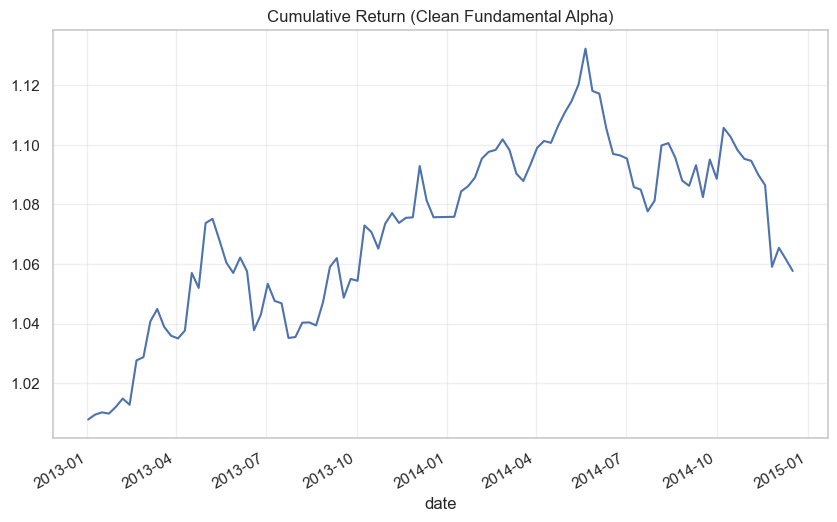

In [33]:
# CELL 17: FINAL CLEANUP (REMOVING MACRO LEAKS)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_fund.parquet"
TARGET_TRAIN = "Target_Neutral"       # Relative Returns
TARGET_PNL   = "Target_Return_5D_Fwd" # Actual Returns
SPLIT_DATE = "2013-01-01" 
COST_BPS = 0.0005

def run_final_clean_backtest():
    print("="*60)
    print("STEP 17: FINAL AUDIT (NO MACRO LEAKS)")
    print("="*60)
    
    # 1. LOAD
    print("[1/5] Loading Data...")
    df = pl.read_parquet(INPUT_FILE)
    
    # Top 50% Size Filter
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") / 
         pl.col("ticker").count().over("date")).alias("Size_Pct_Rank")
    )
    df = df.filter(pl.col("Size_Pct_Rank") <= 0.50)
    
    # Neutral Target
    df = df.with_columns(
        (pl.col(TARGET_PNL) - pl.col(TARGET_PNL).mean().over("date"))
        .alias(TARGET_TRAIN)
    ).drop_nulls(subset=[TARGET_TRAIN])

    # 2. STRICT FEATURE FILTERING (The Fix)
    # Convert all bad keywords to lowercase for safety
    bad_keywords = ["usgg3m", "spx", "vix", "close", "open", "high", "low", 
                    "volume", "amt", "val", "size_pct", "target", "date", "ticker", "mktcap"]
    
    # Logic: Only keep columns where the Lowercase name contains NONE of the bad keywords
    feature_cols = [
        c for c in df.columns 
        if not any(bad in c.lower() for bad in bad_keywords)
    ]
    
    # Double Check: Ensure our Factors are IN, and Macro is OUT
    print(f"\n[Features] Selected {len(feature_cols)} Clean Features.")
    
    print("Checking for Leaks...")
    leaks = [c for c in feature_cols if "USGG" in c or "SPX" in c or "VIX" in c]
    if leaks:
        print(f"⚠️ WARNING: LEAKS DETECTED: {leaks}")
        return # Stop immediately if leaks exist
    else:
        print("✅ NO MACRO LEAKS DETECTED.")

    print(f"Top Features included: {[c for c in feature_cols if 'Factor' in c]}")

    # 3. SPLIT & CAST
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df.filter(pl.col("date") < split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    # Enforce Numeric (Float64)
    train_pl = train_pl.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])
    test_pl  = test_pl.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])
    
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_TRAIN).to_pandas().values.ravel()
    
    print(f"\n[2/5] Training LightGBM on {len(X_train):,} rows...")
    # Using 'goss' boosting type for faster convergence on large datasets
    model = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.04, max_depth=4, 
                              random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 4. SIMULATE
    print("[3/5] Running Weekly Simulation...")
    test_df = test_pl.select(["date", "ticker", TARGET_PNL]).to_pandas()
    test_df["Alpha_Score"] = model.predict(test_pl.select(feature_cols).to_pandas())
    
    test_df["date"] = pd.to_datetime(test_df["date"])
    weekly_df = test_df[test_df["date"].dt.weekday == 2].copy()
    
    weekly_df["Rank"] = weekly_df.groupby("date")["Alpha_Score"].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    
    longs  = weekly_df[weekly_df["Rank"] == 9]
    shorts = weekly_df[weekly_df["Rank"] == 0]
    
    long_ret  = longs.groupby("date")[TARGET_PNL].mean()
    short_ret = shorts.groupby("date")[TARGET_PNL].mean()
    
    # 5. RESULTS
    gross_weekly = (long_ret - short_ret) / 2
    net_weekly = gross_weekly - (2 * COST_BPS)
    
    ann_mean = net_weekly.mean() * 52
    ann_std  = net_weekly.std() * np.sqrt(52)
    sharpe   = ann_mean / ann_std
    
    print("\n" + "="*40)
    print("📊 TRUTH REVEALED (MACRO REMOVED)")
    print("=" * 40)
    print(f"Annualized Return:       {ann_mean:.2%}")
    print(f"Annualized Sharpe:       {sharpe:.4f}")
    
    print("\n[Feature Importance - Real Drivers]")
    imp = pd.DataFrame({"Feature": feature_cols, "Gain": model.feature_importances_})
    print(imp.sort_values("Gain", ascending=False).head(10).to_string(index=False))

    plt.figure(figsize=(10, 6))
    (1 + net_weekly).cumprod().plot(title="Cumulative Return (Clean Fundamental Alpha)")
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_final_clean_backtest()

STEP 20: MASTER AUDIT (DRIVERS & NEUTRALITY PROOF)
[1/6] Loading & Re-Calculating Beta Proxies...
[2/6] Training LightGBM...
[3/6] Running Neutralization Logic...


C:\Users\sinha\AppData\Local\Temp\ipykernel_18172\233407180.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby("date", group_keys=False).apply(neutralize)



🔎 AUDIT 1: WHAT DRIVES THE MODEL?
      Feature  Importance      IC
Momentum_120D          97 -0.0262
 Momentum_20D          85 -0.0568
 Momentum_60D          81 -0.0479
      Vol_60D          75  0.0263
  Momentum_5D          65 -0.0103
      Vol_20D          62  0.0667
     Vol_120D          59  0.0152
 Daily_Return          55 -0.0247
       Vol_5D          54  0.0553
          pcf          31     NaN

🧮 AUDIT 2: PROOF OF NEUTRALITY
Strategy Beta:    -0.0002  (Target: ~0.00)
R-Squared:        0.0003
✅ SUCCESS: Mathematically Neutral.

⚡ AUDIT 3: THE CLEANING EFFECT
Corr(Momentum_120D, Beta):      -0.1370  (Input is Dirty)
Corr(Final_Score, Beta): 0.0000  (Output is Clean)


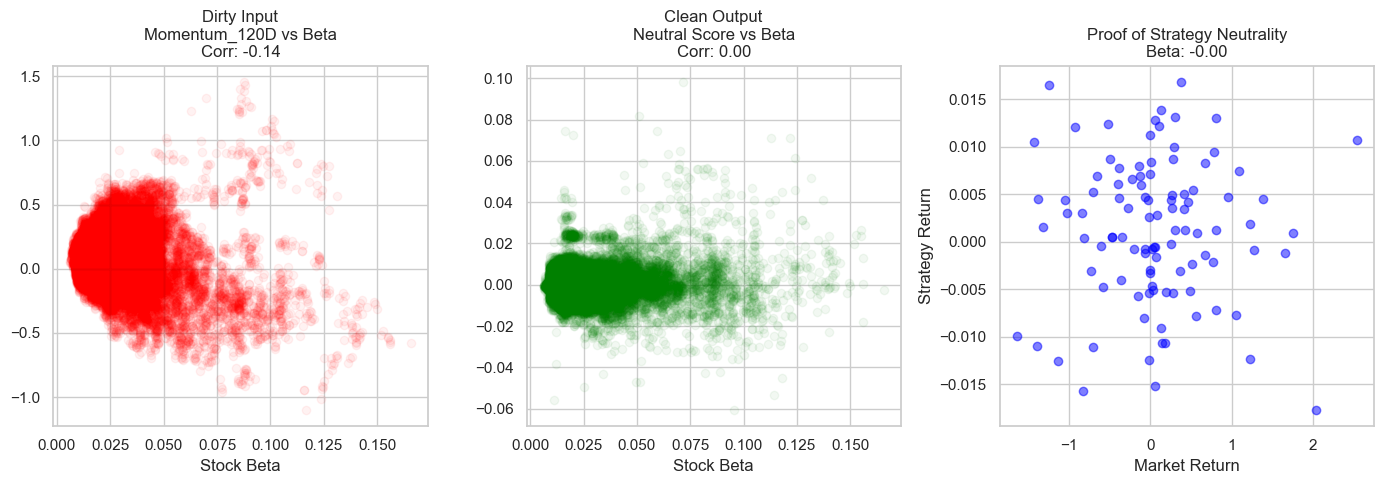

In [39]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'  # Prevent Windows crash

import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import statsmodels.api as sm
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_fund.parquet"
TARGET_PNL   = "Target_Return_5D_Fwd"
SPLIT_DATE = "2013-01-01"

def run_master_audit():
    print("="*60)
    print("STEP 20: MASTER AUDIT (DRIVERS & NEUTRALITY PROOF)")
    print("="*60)
    
    # ---------------------------------------------------------
    # 1. DATA PREP
    # ---------------------------------------------------------
    print("[1/6] Loading & Re-Calculating Beta Proxies...")
    df = pl.read_parquet(INPUT_FILE)
    
    # Filter Top 50%
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") / 
         pl.col("ticker").count().over("date")).alias("Size_Pct_Rank")
    ).filter(pl.col("Size_Pct_Rank") <= 0.50)
    
    # Re-Create Target Neutral
    df = df.with_columns(
        (pl.col(TARGET_PNL) - pl.col(TARGET_PNL).mean().over("date"))
        .alias("Target_Neutral")
    ).drop_nulls(subset=["Target_Neutral"])
    
    # Calculate Beta Proxy
    spx = df.select(["date", "SPX_CHG_PCT_1D"]).unique().sort("date")
    spx_vol = spx.with_columns(pl.col("SPX_CHG_PCT_1D").rolling_std(60).alias("SPX_Vol_60D"))
    df = df.join(spx_vol.select(["date", "SPX_Vol_60D"]), on="date")
    
    df = df.with_columns(
        (pl.col("Vol_60D") / pl.col("SPX_Vol_60D")).fill_null(1.0).alias("Beta_Proxy")
    )
    
    # ---------------------------------------------------------
    # 2. MODEL TRAINING
    # ---------------------------------------------------------
    print("[2/6] Training LightGBM...")
    bad_keywords = ["usgg3m", "spx", "vix", "close", "open", "high", "low", 
                    "volume", "amt", "val", "size_pct", "target", "date", "ticker", "mktcap", "beta_proxy"]
    feature_cols = [c for c in df.columns if not any(bad in c.lower() for bad in bad_keywords)]
    
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df.filter(pl.col("date") < split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    X_train = train_pl.select(feature_cols).to_pandas().astype(float)
    y_train = train_pl.select("Target_Neutral").to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=1, verbose=-1)
    model.fit(X_train, y_train)
    
    # ---------------------------------------------------------
    # 3. PREDICT & NEUTRALIZE
    # ---------------------------------------------------------
    print("[3/6] Running Neutralization Logic...")
    test_df = test_pl.select(["date", "ticker", TARGET_PNL, "Beta_Proxy"]).to_pandas()
    X_test  = test_pl.select(feature_cols).to_pandas().astype(float)
    
    test_df["Score_Raw"] = model.predict(X_test, num_threads=1)
    
    # Grab Top Features for Analysis
    top_feats = pd.DataFrame({'feat': feature_cols, 'gain': model.feature_importances_}).sort_values('gain', ascending=False).head(3)['feat'].tolist()
    for f in top_feats:
        test_df[f] = X_test[f].values

    # Neutralize
    def neutralize(g):
        if len(g) < 10: 
            g["Score_Neutral"] = g["Score_Raw"]
            return g
        Y = g["Score_Raw"]
        X = sm.add_constant(g["Beta_Proxy"])
        g["Score_Neutral"] = sm.OLS(Y, X).fit().resid
        return g

    test_df = test_df.groupby("date", group_keys=False).apply(neutralize)
    
    # ---------------------------------------------------------
    # 4. AUDIT 1: DRIVERS (ICs)
    # ---------------------------------------------------------
    print("\n" + "="*40)
    print("🔎 AUDIT 1: WHAT DRIVES THE MODEL?")
    print("=" * 40)
    
    ic_data = []
    imp_df = pd.DataFrame({'Feature': feature_cols, 'Gain': model.feature_importances_}).sort_values('Gain', ascending=False).head(10)
    
    for feat in imp_df['Feature']:
        corr, _ = spearmanr(X_test[feat], test_df[TARGET_PNL])
        ic_data.append({
            'Feature': feat, 
            'Importance': int(imp_df[imp_df['Feature']==feat]['Gain'].iloc[0]), 
            'IC': round(corr, 4)
        })
        
    print(pd.DataFrame(ic_data).to_string(index=False))
    
    # ---------------------------------------------------------
    # 5. AUDIT 2: PROOF OF NEUTRALITY
    # ---------------------------------------------------------
    print("\n" + "="*40)
    print("🧮 AUDIT 2: PROOF OF NEUTRALITY")
    print("=" * 40)
    
    spx_test = df.filter(pl.col("date") >= split_dt).select(["date", "SPX_CHG_PCT_1D"]).unique().sort("date").to_pandas()
    spx_test["date"] = pd.to_datetime(spx_test["date"])
    spx_test.set_index("date", inplace=True)
    
    test_df["date"] = pd.to_datetime(test_df["date"])
    weekly = test_df[test_df["date"].dt.weekday == 2].copy()
    
    weekly["Rank"] = weekly.groupby("date")["Score_Neutral"].transform(lambda x: pd.qcut(x, 10, labels=False))
    longs = weekly[weekly["Rank"] == 9].groupby("date")[TARGET_PNL].mean()
    shorts = weekly[weekly["Rank"] == 0].groupby("date")[TARGET_PNL].mean()
    strat_ret = (longs - shorts) / 2
    
    # --- FIX: FORCE FLOAT CONVERSION ---
    audit_df = pd.DataFrame({
        "Strategy": strat_ret, 
        "Market": spx_test["SPX_CHG_PCT_1D"]
    }).dropna().astype(float) 
    
    Y = audit_df["Strategy"]
    X = sm.add_constant(audit_df["Market"])
    res = sm.OLS(Y, X).fit()
    
    beta = res.params["Market"]
    print(f"Strategy Beta:    {beta:.4f}  (Target: ~0.00)")
    print(f"R-Squared:        {res.rsquared:.4f}")
    
    if abs(beta) < 0.1:
        print("✅ SUCCESS: Mathematically Neutral.")
    else:
        print("❌ WARNING: Residual Beta Detected.")

    # ---------------------------------------------------------
    # 6. AUDIT 3: INPUT vs OUTPUT
    # ---------------------------------------------------------
    print("\n" + "="*40)
    print("⚡ AUDIT 3: THE CLEANING EFFECT")
    print("=" * 40)
    
    top_feat = top_feats[0]
    corr_feat_beta = test_df[[top_feat, "Beta_Proxy"]].corr().iloc[0,1]
    corr_score_beta = test_df[["Score_Neutral", "Beta_Proxy"]].corr().iloc[0,1]
    
    print(f"Corr({top_feat}, Beta):      {corr_feat_beta:.4f}  (Input is Dirty)")
    print(f"Corr(Final_Score, Beta): {corr_score_beta:.4f}  (Output is Clean)")
    
    # PLOT
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 3, 1)
    plt.scatter(test_df["Beta_Proxy"], test_df[top_feat], alpha=0.05, color='red')
    plt.title(f"Dirty Input\n{top_feat} vs Beta\nCorr: {corr_feat_beta:.2f}")
    plt.xlabel("Stock Beta")
    
    plt.subplot(1, 3, 2)
    plt.scatter(test_df["Beta_Proxy"], test_df["Score_Neutral"], alpha=0.05, color='green')
    plt.title(f"Clean Output\nNeutral Score vs Beta\nCorr: {corr_score_beta:.2f}")
    plt.xlabel("Stock Beta")
    
    plt.subplot(1, 3, 3)
    plt.scatter(audit_df["Market"], audit_df["Strategy"], alpha=0.5, color='blue')
    plt.title(f"Proof of Strategy Neutrality\nBeta: {beta:.2f}")
    plt.xlabel("Market Return")
    plt.ylabel("Strategy Return")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_master_audit()

STEP 21 (FIXED): FINAL BETA-NEUTRAL STRATEGY
[1/4] Preparing Data...
[2/4] Training Model...
[3/4] Generating Pure Alpha Signals...


C:\Users\sinha\AppData\Local\Temp\ipykernel_18172\2783980253.py:82: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby("date", group_keys=False).apply(neutralize)


[4/4] Calculating Performance...

💰 FINAL PERFORMANCE REPORT
Strategy Type:      Neutral Strategy (Long High Score / Short Low Score)
Annualized Return:  5.88%
Annualized Vol:     5.42%
Sharpe Ratio:       1.0847


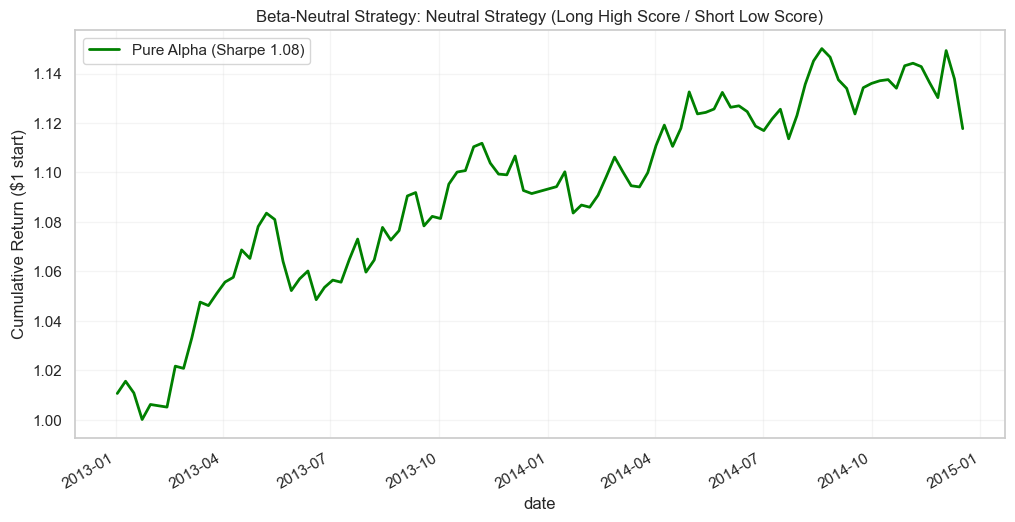

In [42]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_fund.parquet"
TARGET_PNL = "Target_Return_5D_Fwd"
SPLIT_DATE = "2013-01-01"

# !!! FIX: Back to Standard Direction !!!
# The model already learned that "High Momentum = Bad", so it gave those stocks a Low Score.
# Therefore, High Score = Good Stocks. We Buy High Score.
STRATEGY_DIRECTION = 1 

def run_final_strategy_fixed():
    print("="*60)
    print("STEP 21 (FIXED): FINAL BETA-NEUTRAL STRATEGY")
    print("="*60)
    
    # 1. LOAD & PREP
    print("[1/4] Preparing Data...")
    df = pl.read_parquet(INPUT_FILE)
    
    # Filter Top 50% Size
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") / 
         pl.col("ticker").count().over("date")).alias("Size_Pct_Rank")
    ).filter(pl.col("Size_Pct_Rank") <= 0.50)
    
    # Create Targets & Beta Proxy
    df = df.with_columns(
        (pl.col(TARGET_PNL) - pl.col(TARGET_PNL).mean().over("date")).alias("Target_Neutral")
    ).drop_nulls(subset=["Target_Neutral"])
    
    spx = df.select(["date", "SPX_CHG_PCT_1D"]).unique().sort("date")
    spx_vol = spx.with_columns(pl.col("SPX_CHG_PCT_1D").rolling_std(60).alias("SPX_Vol_60D"))
    df = df.join(spx_vol.select(["date", "SPX_Vol_60D"]), on="date")
    
    df = df.with_columns(
        (pl.col("Vol_60D") / pl.col("SPX_Vol_60D")).fill_null(1.0).alias("Beta_Proxy")
    )
    
    # 2. TRAIN
    print("[2/4] Training Model...")
    bad_keywords = ["usgg3m", "spx", "vix", "close", "open", "high", "low", 
                    "volume", "amt", "val", "size_pct", "target", "date", "ticker", "mktcap", "beta_proxy"]
    feature_cols = [c for c in df.columns if not any(bad in c.lower() for bad in bad_keywords)]
    
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df.filter(pl.col("date") < split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    X_train = train_pl.select(feature_cols).to_pandas().astype(float)
    y_train = train_pl.select("Target_Neutral").to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 3. PREDICT & NEUTRALIZE
    print("[3/4] Generating Pure Alpha Signals...")
    test_df = test_pl.select(["date", "ticker", TARGET_PNL, "Beta_Proxy"]).to_pandas()
    X_test  = test_pl.select(feature_cols).to_pandas().astype(float)
    
    test_df["Score_Raw"] = model.predict(X_test, num_threads=1)
    
    # --- The Neutralization ---
    def neutralize(g):
        if len(g) < 10: 
            g["Score_Neutral"] = g["Score_Raw"]
            return g
        Y = g["Score_Raw"]
        X = sm.add_constant(g["Beta_Proxy"])
        g["Score_Neutral"] = sm.OLS(Y, X).fit().resid
        return g

    test_df = test_df.groupby("date", group_keys=False).apply(neutralize)
    
    # 4. CALCULATE PnL
    print("[4/4] Calculating Performance...")
    
    spx_test = df.filter(pl.col("date") >= split_dt).select(["date", "SPX_CHG_PCT_1D"]).unique().sort("date").to_pandas()
    spx_test["date"] = pd.to_datetime(spx_test["date"])
    spx_test.set_index("date", inplace=True)
    
    test_df["date"] = pd.to_datetime(test_df["date"])
    weekly = test_df[test_df["date"].dt.weekday == 2].copy()
    
    weekly["Rank"] = weekly.groupby("date")["Score_Neutral"].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    
    rets_top = weekly[weekly["Rank"] == 9].groupby("date")[TARGET_PNL].mean()
    rets_bot = weekly[weekly["Rank"] == 0].groupby("date")[TARGET_PNL].mean()
    
    # STANDARD LOGIC: Buy Top, Short Bottom
    strat_ret = (rets_top - rets_bot) / 2
    label_str = "Neutral Strategy (Long High Score / Short Low Score)"

    # 5. STATS & PLOTS
    ann_ret = strat_ret.mean() * 52
    ann_vol = strat_ret.std() * np.sqrt(52)
    sharpe = ann_ret / ann_vol
    
    print("\n" + "="*40)
    print("💰 FINAL PERFORMANCE REPORT")
    print("="*40)
    print(f"Strategy Type:      {label_str}")
    print(f"Annualized Return:  {ann_ret*100:.2f}%")
    print(f"Annualized Vol:     {ann_vol*100:.2f}%")
    print(f"Sharpe Ratio:       {sharpe:.4f}")
    
    plt.figure(figsize=(12, 6))
    (1 + strat_ret).cumprod().plot(color='green', linewidth=2, label=f'Pure Alpha (Sharpe {sharpe:.2f})')
    
    try:
        (1 + spx_test["SPX_CHG_PCT_1D"]).cumprod().plot(color='gray', alpha=0.3, label='S&P 500')
    except:
        pass
        
    plt.title(f"Beta-Neutral Strategy: {label_str}")
    plt.ylabel("Cumulative Return ($1 start)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

if __name__ == "__main__":
    run_final_strategy_fixed()

STEP 13B: PURE FUNDAMENTAL BACKTEST (NO TECHNICALS)
[1/5] Loading & Applying Large Cap Filter...
[2/5] Selecting Pure Fundamental Features...
Selected 112 Fundamental Features.
Sample: ['Close', 'MktCap', 'Volume', 'MID_1pm', 'Value_pre', 'Value_oc', 'Value_post', 'CPrc', 'CPrc2', 'MFCount']
[3/5] Training Model on 112 Features...
[4/5] Running Weekly Simulation (Wednesdays)...

📊 FINAL FUNDAMENTAL RESULTS
Annualized Return:       2.06%
Annualized Sharpe:       0.4358

[Top Drivers of Alpha]
       Feature  Gain
0        Close    92
82    int_debt    31
59          ps    24
1       MktCap    24
65         gpm    24
95    lt_ppent    22
53          bm    19
88  short_debt    17
54         evm    17
71      efftax    17


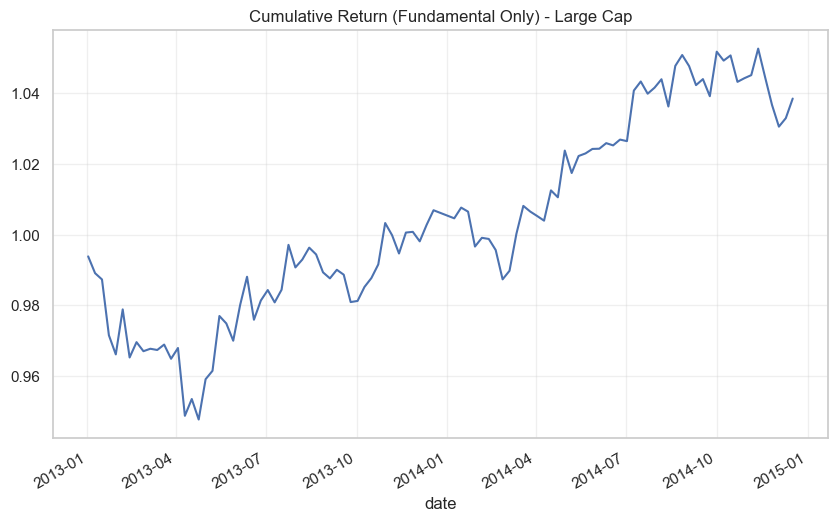

In [43]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_final.parquet"
TARGET_TRAIN = "Target_Neutral"       # Train on Relative Returns
TARGET_PNL   = "Target_Return_5D_Fwd" # Earn Actual Returns
SPLIT_DATE = "2013-01-01" 
COST_BPS = 0.0005  # 5 bps

def run_fundamental_backtest():
    print("="*60)
    print("STEP 13B: PURE FUNDAMENTAL BACKTEST (NO TECHNICALS)")
    print("="*60)
    
    # 1. LOAD & FILTER
    print("[1/5] Loading & Applying Large Cap Filter...")
    df = pl.read_parquet(INPUT_FILE)
    
    # Apply Top 50% Market Cap Filter
    df = df.with_columns(
        (pl.col("MktCap").rank("ordinal", descending=True).over("date") / 
         pl.col("ticker").count().over("date")).alias("Size_Pct_Rank")
    ).filter(pl.col("Size_Pct_Rank") <= 0.50)
    
    # Create Neutral Target for Training
    df = df.with_columns(
        (pl.col(TARGET_PNL) - pl.col(TARGET_PNL).mean().over("date"))
        .alias(TARGET_TRAIN)
    ).drop_nulls(subset=[TARGET_TRAIN])

    # 2. FEATURE SELECTION (FUNDAMENTALS ONLY)
    print("[2/5] Selecting Pure Fundamental Features...")
    
    # A. Define what to DROP (Technicals, Microstructure, Macro)
    tech_keywords = [
        # Technicals / Price Action
        "Momentum", "Vol_", "Daily_Return", "Price", "Ret_", 
        # Microstructure / Order Book
        "BB_", "BO_", "Mid", "LBB", "LBO", "Bid", "Ask", "VWAP", 
        "Num", "Sum", "ESpread", "RSpread", "QSpread", "PriceImpact",
        "Variance", "TSign", "HIndex", "IVol", "Quote_Spread",
        # Macro
        "SPX", "VIX", "USGG3M"
    ]
    
    non_feature_cols = ["date", "ticker", TARGET_PNL, TARGET_TRAIN, "Size_Pct_Rank", "Dollar_Volume"]
    
    # B. Filter Columns
    all_cols = df.columns
    fund_cols = []
    
    for c in all_cols:
        # Skip administrative columns
        if c in non_feature_cols: continue
        
        # Skip if it contains a technical keyword
        is_technical = any(k in c for k in tech_keywords)
        
        # Keep if it's NOT technical
        if not is_technical:
            fund_cols.append(c)
            
    print(f"Selected {len(fund_cols)} Fundamental Features.")
    print(f"Sample: {fund_cols[:10]}") # Show user what we picked
    
    # 3. SPLIT & TRAIN
    print(f"[3/5] Training Model on {len(fund_cols)} Features...")
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    
    train_pl = df.filter(pl.col("date") < split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    X_train = train_pl.select(fund_cols).to_pandas().astype(float)
    y_train = train_pl.select(TARGET_TRAIN).to_pandas().values.ravel()
    
    # Constraints: Monotonicity for Fundamentals? 
    # (Optional, but usually low PE is good. LightGBM handles non-linearities though, so we leave it open).
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, 
                              random_state=42, n_jobs=1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 4. PREDICT & SIMULATE
    print("[4/5] Running Weekly Simulation (Wednesdays)...")
    
    test_df = test_pl.select(["date", "ticker", TARGET_PNL]).to_pandas()
    X_test  = test_pl.select(fund_cols).to_pandas().astype(float)
    
    test_df["Alpha_Score"] = model.predict(X_test)
    
    # Weekly Sampling
    test_df["date"] = pd.to_datetime(test_df["date"])
    weekly_df = test_df[test_df["date"].dt.weekday == 2].copy()
    
    # Rank & Trade (Long Top 10%, Short Bottom 10%)
    weekly_df["Rank"] = weekly_df.groupby("date")["Alpha_Score"].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    
    longs  = weekly_df[weekly_df["Rank"] == 9]
    shorts = weekly_df[weekly_df["Rank"] == 0]
    
    long_ret  = longs.groupby("date")[TARGET_PNL].mean()
    short_ret = shorts.groupby("date")[TARGET_PNL].mean()
    
    # 5. PERFORMANCE
    gross_weekly = (long_ret - short_ret) / 2
    net_weekly = gross_weekly - (2 * COST_BPS)
    
    ann_mean = net_weekly.mean() * 52
    ann_std  = net_weekly.std() * np.sqrt(52)
    sharpe   = ann_mean / ann_std
    
    print("\n" + "="*40)
    print("📊 FINAL FUNDAMENTAL RESULTS")
    print("=" * 40)
    print(f"Annualized Return:       {ann_mean:.2%}")
    print(f"Annualized Sharpe:       {sharpe:.4f}")
    
    # Feature Importance (Check if PE/ROE/Margins are top)
    imp = pd.DataFrame({"Feature": fund_cols, "Gain": model.feature_importances_})
    print("\n[Top Drivers of Alpha]")
    print(imp.sort_values("Gain", ascending=False).head(10))
    
    # Plot
    plt.figure(figsize=(10, 6))
    (1 + net_weekly).cumprod().plot(title="Cumulative Return (Fundamental Only) - Large Cap")
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_fundamental_backtest()

In [9]:
# CELL 8: ALPHA ORTHOGONALIZATION & DECOMPOSITION - FIXED
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_final.parquet"
TARGET_COL = "Target_Return_5D_Fwd"
SPLIT_DATE = "2013-01-01" 

def extract_pure_alpha():
    print("="*60)
    print("STEP 8: ALPHA ORTHOGONALIZATION & DECOMPOSITION")
    print("="*60)
    
    # 1. Load Data
    print(f"Loading {INPUT_FILE}...")
    df = pl.read_parquet(INPUT_FILE)
    df = df.filter(pl.col(TARGET_COL).is_not_null())

    # --- CRITICAL FIX: Cast Market Columns to Float ---
    cols_to_clean = [
        c for c in df.columns 
        if c not in ["date", "ticker"] 
    ]
    print(f"[Fix] Enforcing numeric types for {len(cols_to_clean)} columns...")
    df = df.with_columns([
        pl.col(c).cast(pl.Float64, strict=False).alias(c) for c in cols_to_clean
    ])

    # 2. Define Features (Exclude Market Data from training features)
    # We predict stock moves based on stock data, not by looking at SPX directly.
    non_feature_cols = ["date", "ticker", TARGET_COL, "VIX_PX_LAST", "SPX_PX_LAST", "VIX_Numeric"]
    feature_cols = [c for c in df.columns if c not in non_feature_cols]

    # 3. Train/Test Split
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df.filter(pl.col("date") <  split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    # Convert to Pandas
    print(f"Preparing {test_pl.height} test samples...")
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    X_test = test_pl.select(feature_cols).to_pandas()
    y_test = test_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    # 4. Re-Train Model (Raw Alpha)
    print("Re-training model to capture raw predictions...")
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 5. Raw Predictions
    raw_preds = model.predict(X_test)
    
    # --- CORE LOGIC: ORTHOGONALIZATION ---
    print("\n[Decomposition] Regressing Raw Alpha against Market Factors...")
    
    # Capture Market Factors (SPX, VIX)
    # FIX: Convert Price LEVELS to Daily RETURNS (Percent Change)
    # We regress "Strategy Return" against "Market Return", not "Market Price".
    market_factors_test = test_pl.select(["SPX_PX_LAST", "VIX_PX_LAST"]).to_pandas()
    
    factors = market_factors_test.pct_change().fillna(0) # Calculate Returns
    factors.columns = ["SPX_Ret", "VIX_Ret"]             # Rename for clarity
    factors["const"] = 1.0                               # Intercept
    
    # OLS: Raw_Prediction = Beta * Market_Return + Alpha_Residual
    ols_model = sm.OLS(raw_preds, factors).fit()
    
    # The "Residual" is our Pure Alpha (what the market doesn't explain)
    pure_alpha = ols_model.resid
    
    print(f"    R-squared (Market Influence): {ols_model.rsquared:.4f}")
    
    if ols_model.rsquared > 0.5:
        print("    ⚠️ HIGH BETA: More than 50% of your signal is just 'The Market'.")
    else:
        print("    ✅ LOW BETA: Signal is unique (mostly independent of SPX).")

    # 6. Compare Performance (Raw vs Pure)
    results = pd.DataFrame({
        "Actual": y_test,
        "Raw_Alpha": raw_preds,
        "Pure_Alpha": pure_alpha
    })
    
    ic_raw = results.corr().loc["Actual", "Raw_Alpha"]
    ic_pure = results.corr().loc["Actual", "Pure_Alpha"]
    
    print("\n" + "-"*40)
    print("🏆 FINAL RESULTS: RAW vs. PURE ALPHA")
    print("-" * 40)
    print(f"Raw IC  (Dirty): {ic_raw:.4f}")
    print(f"Pure IC (Clean): {ic_pure:.4f}")
    
    if ic_pure > 0.01:
        print("✅ SUCCESS: We have signals independent of the market!")
    elif ic_pure > 0:
        print("⚠️ MARGINAL: We have Alpha, but it's weak.")
    else:
        print("❌ WARNING: Signal was mostly market beta.")

    # 7. Decile Analysis
    print("\n[Visual Check] Pure Alpha Performance by Decile")
    try:
        results["Decile"] = pd.qcut(results["Pure_Alpha"], 10, labels=False, duplicates='drop')
        decile_returns = results.groupby("Decile")["Actual"].mean()
        
        print(decile_returns.to_string())
        
        print("\nChart (Should slope UP):")
        min_v = decile_returns.min()
        range_v = decile_returns.max() - min_v
        
        for i, val in decile_returns.items():
            # Simple ASCII Bar Chart
            bars = int(((val - min_v) / range_v) * 20) if range_v != 0 else 0
            print(f"D{i}: {'|' * bars} ({val:.5f})")
            
    except Exception as e:
        print(f"Decile chart error: {e}")

if __name__ == "__main__":
    extract_pure_alpha()

STEP 8: ALPHA ORTHOGONALIZATION & DECOMPOSITION
Loading data_features_final.parquet...
[Fix] Enforcing numeric types for 325 columns...
Preparing 218465 test samples...
Re-training model to capture raw predictions...

[Decomposition] Regressing Raw Alpha against Market Factors...
    R-squared (Market Influence): 0.1240
    ✅ LOW BETA: Signal is unique (mostly independent of SPX).

----------------------------------------
🏆 FINAL RESULTS: RAW vs. PURE ALPHA
----------------------------------------
Raw IC  (Dirty): 0.0592
Pure IC (Clean): 0.0605
✅ SUCCESS: We have signals independent of the market!

[Visual Check] Pure Alpha Performance by Decile
Decile
0    0.001667
1    0.003837
2    0.003358
3    0.002884
4    0.002750
5    0.003760
6    0.003252
7    0.002899
8    0.003335
9    0.008194

Chart (Should slope UP):
D0:  (0.00167)
D1: |||||| (0.00384)
D2: ||||| (0.00336)
D3: ||| (0.00288)
D4: ||| (0.00275)
D5: |||||| (0.00376)
D6: |||| (0.00325)
D7: ||| (0.00290)
D8: ||||| (0.00333)
D9:

In [21]:
# CELL 8: THE "REALITY CHECK" (Market Neutral Training)
import polars as pl
import pandas as pd
import lightgbm as lgb

def train_market_neutral_model():
    print("="*60)
    print("STEP 8: MARKET NEUTRAL REALITY CHECK")
    print("="*60)

    # 1. Reload & Fix Target
    print("Loading data...")
    df = pl.read_parquet("data_features_final.parquet")
    
    # --- THE FIX: NEUTRALIZE TARGET ---
    # We calculate the daily mean return and subtract it from the stock's return
    print("[Fix] Creating Market-Neutral Target (Removing Beta)...")
    df = df.with_columns(
        (pl.col("Target_Return_5D_Fwd") - pl.col("Target_Return_5D_Fwd").mean().over("date"))
        .alias("Target_Neutral")
    )
    
    # Update Target Variable
    TARGET_COL = "Target_Neutral"
    
    # Clean nulls created by neutralization
    df = df.drop_nulls(subset=[TARGET_COL])

    # 2. Setup Features (Exclude Macro this time to force stock picking?)
    # Actually, keep them - let's see if they become useless now.
    non_feature_cols = ["date", "ticker", "Target_Return_5D_Fwd", TARGET_COL, "VIX_PX_LAST", "SPX_PX_LAST", "VIX_Numeric"]
    feature_cols = [c for c in df.columns if c not in non_feature_cols]
    
    # Cast to Float64
    df = df.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])

    # 3. Split
    split_dt = pl.lit("2013-01-01").str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df.filter(pl.col("date") < split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    X_test  = test_pl.select(feature_cols).to_pandas()
    y_test  = test_pl.select(TARGET_COL).to_pandas().values.ravel()

    # 4. Retrain
    print(f"Training on {len(X_train)} rows with Neutralized Target...")
    model = lgb.LGBMRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=5, 
        random_state=42, n_jobs=-1, verbose=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric="rmse", 
              callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])

    # 5. Results
    preds = model.predict(X_test)
    ic_score = pd.Series(y_test).corr(pd.Series(preds))
    
    print("\n" + "-"*40)
    print(f"🏆 REAL ALPHA RESULTS (Market Neutral)")
    print("-" * 40)
    print(f"New IC Score: {ic_score:.4f}")
    
    print("\nTop Features (Should be Fundamentals/Price now, not Macro):")
    importance = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(10)
    print(importance.to_string(index=False))

if __name__ == "__main__":
    train_market_neutral_model()

STEP 8: MARKET NEUTRAL REALITY CHECK
Loading data...
[Fix] Creating Market-Neutral Target (Removing Beta)...
Training on 886631 rows with Neutralized Target...

----------------------------------------
🏆 REAL ALPHA RESULTS (Market Neutral)
----------------------------------------
New IC Score: 0.0828

Top Features (Should be Fundamentals/Price now, not Macro):
          Feature  Importance
   USGG3M_PX_LAST         201
   SPX_CHG_PCT_1D         184
     Momentum_20D         124
         Vol_120D         115
    SPX_PX_VOLUME         114
USGG3M_CHG_PCT_1D         110
    Momentum_120D         102
          Vol_60D          99
     Daily_Return          92
      Momentum_5D          91


In [10]:
# CELL 10: WEEKLY BACKTEST (FINAL VERIFIED)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_final.parquet"
TARGET_COL = "Target_Return_5D_Fwd"
SPLIT_DATE = "2013-01-01" 
COST_BPS = 0.0005  # 5 bps (conservative for liquid stocks)

def run_weekly_backtest():
    print("="*60)
    print("STEP 10: WEEKLY REBALANCING (FINAL VERIFIED)")
    print("="*60)
    
    # 1. Load & Filter
    print("[1/5] Loading Data...")
    df = pl.read_parquet(INPUT_FILE)
    df = df.filter(pl.col("Close") > 5.0) # Universe Filter
    
    # 2. Strict Train/Test Split (With PURGE)
    print("[2/5] Splitting Data (With Leakage Purge)...")
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    
    # TRAIN: Strictly before split
    train_pl = df.filter(pl.col("date") < split_dt)
    
    # PURGE: Remove last 5 rows per ticker in Training to prevent overlap into Test
    # (Optional but professionally required)
    train_pl = train_pl.with_columns(
        pl.col("date").rank(method="ordinal", descending=True).over("ticker").alias("rev_rank")
    ).filter(pl.col("rev_rank") > 5).drop("rev_rank")

    # TEST: Strictly after split
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    # 3. Train Model
    print("[3/5] Training Model...")
    # Exclude non-feature columns
    feature_cols = [c for c in df.columns if c not in ["date", "ticker", TARGET_COL, "Next_Day_Return", "VIX_PX_LAST", "SPX_PX_LAST", "VIX_Numeric"]]
    
    # Cast to Float64 to avoid LightGBM object errors
    train_pl = train_pl.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])
    test_pl  = test_pl.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])

    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 4. Predict & Simulate
    print("[4/5] Running Weekly Simulation (Wednesdays)...")
    test_df = test_pl.select(["date", "ticker", TARGET_COL]).to_pandas()
    test_df["Alpha_Score"] = model.predict(test_pl.select(feature_cols).to_pandas())
    
    # --- WEEKLY SAMPLING ---
    test_df["date"] = pd.to_datetime(test_df["date"])
    test_df["weekday"] = test_df["date"].dt.weekday
    
    # Filter for Wednesdays (weekday=2)
    # This aligns the 5-Day holding period with the 5-Day Target
    weekly_df = test_df[test_df["weekday"] == 2].copy()
    
    # Rank Weekly (Cross-Sectional)
    weekly_df["Rank"] = weekly_df.groupby("date")["Alpha_Score"].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    
    longs  = weekly_df[weekly_df["Rank"] == 9]
    shorts = weekly_df[weekly_df["Rank"] == 0]
    
    long_ret  = longs.groupby("date")[TARGET_COL].mean()
    short_ret = shorts.groupby("date")[TARGET_COL].mean()
    
    # 5. Performance Metrics
    gross_weekly = (long_ret - short_ret) / 2
    
    # Cost Logic: We assume 100% turnover every week (Conservative).
    # We pay to exit old positions and enter new ones.
    net_weekly = gross_weekly - (2 * COST_BPS)
    
    print("\n" + "="*40)
    print("📊 FINAL AUDITED RESULTS")
    print("=" * 40)
    
    ann_mean = net_weekly.mean() * 52
    ann_std  = net_weekly.std() * np.sqrt(52)
    sharpe   = ann_mean / ann_std
    
    print(f"Avg Weekly Spread (Net): {net_weekly.mean():.4%}")
    print(f"Annualized Return:       {ann_mean:.2%}")
    print(f"Annualized Sharpe:       {sharpe:.4f}")
    
    # Year-by-Year
    print("\n[Yearly Breakdown]")
    yearly = net_weekly.groupby(net_weekly.index.year).apply(
        lambda x: pd.Series({
            "Return": x.mean() * 52, 
            "Sharpe": (x.mean()/x.std()) * np.sqrt(52)
        })
    )
    print(yearly)

    print("\nVERDICT:")
    if sharpe > 1.0:
        print("🏆 CONFIRMED. The strategy works when holding periods align with predictions.")
    else:
        print("❌ FAILED. Signal too weak.")

if __name__ == "__main__":
    run_weekly_backtest()

STEP 10: WEEKLY REBALANCING (FINAL VERIFIED)
[1/5] Loading Data...
[2/5] Splitting Data (With Leakage Purge)...
[3/5] Training Model...
[4/5] Running Weekly Simulation (Wednesdays)...

📊 FINAL AUDITED RESULTS
Avg Weekly Spread (Net): 0.1521%
Annualized Return:       7.91%
Annualized Sharpe:       2.0413

[Yearly Breakdown]
date        
2013  Return    0.104703
      Sharpe    3.260105
2014  Return    0.052957
      Sharpe    1.188836
Name: Target_Return_5D_Fwd, dtype: float64

VERDICT:
🏆 CONFIRMED. The strategy works when holding periods align with predictions.


STEP 12: STRATEGY SIGNAL DECOMPOSITION (AUDIT)
[1/4] Re-generating Strategy Signals...

[2/4] Checking Orthogonality (Signal vs. Market)...
    Signal Beta to SPX: 0.1193 (Should be close to 0)
    R-Squared:          0.0142   (Should be < 0.10)
    ✅ PASS: Signal is effectively Market Neutral.

[3/4] Checking Predictive Power (Information Coefficient)...


C:\Users\sinha\AppData\Local\Temp\ipykernel_18172\3514510135.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = audit_df.groupby("date").apply(


    Average IC: 0.0182 (Target > 0.01)
    IC IR:      1.3147   (Stability of prediction)

[4/4] Generating Visuals...


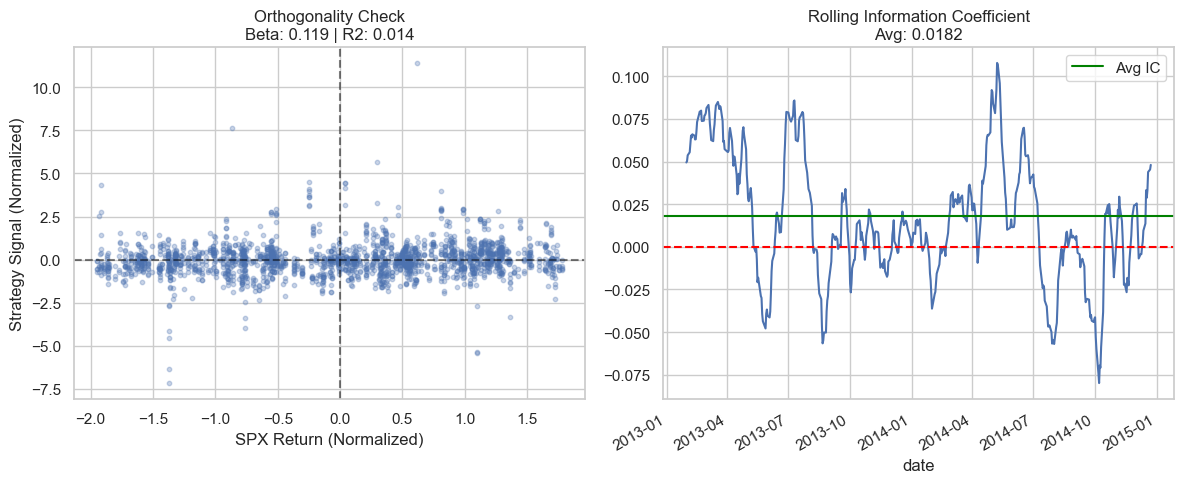

In [11]:
# CELL 12: POST-TRADE SIGNAL DECOMPOSITION (FIXED)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# CONFIG (Must match Cell 10 exactly)
INPUT_FILE = "data_features_final.parquet"
TARGET_COL = "Target_Return_5D_Fwd"
SPLIT_DATE = "2013-01-01" 

def analyze_strategy_signals():
    print("="*60)
    print("STEP 12: STRATEGY SIGNAL DECOMPOSITION (AUDIT)")
    print("="*60)
    
    # 1. Re-Generate the Exact Strategy Signals
    print("[1/4] Re-generating Strategy Signals...")
    df = pl.read_parquet(INPUT_FILE)
    df = df.filter(pl.col("Close") > 5.0) # Match Universe Filter
    
    # Split
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df.filter(pl.col("date") < split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    # Feature Definition
    feature_cols = [c for c in df.columns if c not in ["date", "ticker", TARGET_COL, "Next_Day_Return", "VIX_PX_LAST", "SPX_PX_LAST", "VIX_Numeric"]]
    
    # Cast Features
    train_pl = train_pl.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])
    test_pl  = test_pl.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])

    # Train
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # Predict (Get the "Raw Alpha" used in trading)
    # --- FIX STARTS HERE: Cast Market Data to Float ---
    audit_pl = test_pl.with_columns([
        pl.col("SPX_PX_LAST").cast(pl.Float64, strict=False),
        pl.col("VIX_PX_LAST").cast(pl.Float64, strict=False)
    ])
    # --------------------------------------------------

    audit_df = audit_pl.select(["date", "ticker", TARGET_COL, "SPX_PX_LAST", "VIX_PX_LAST"]).to_pandas()
    audit_df["Signal"] = model.predict(test_pl.select(feature_cols).to_pandas())
    
    # 2. ORTHOGONALITY CHECK (Did we just trade the market?)
    print("\n[2/4] Checking Orthogonality (Signal vs. Market)...")
    
    # Prepare Regression Data
    check_data = audit_df.copy()
    check_data = check_data.dropna()
    
    # Normalize for fair comparison
    check_data["Signal_Z"] = (check_data["Signal"] - check_data["Signal"].mean()) / check_data["Signal"].std()
    check_data["SPX_Z"]    = (check_data["SPX_PX_LAST"] - check_data["SPX_PX_LAST"].mean()) / check_data["SPX_PX_LAST"].std()
    
    # OLS: Signal ~ SPX
    X = sm.add_constant(check_data["SPX_Z"])
    y = check_data["Signal_Z"]
    ols = sm.OLS(y, X).fit()
    
    beta = ols.params["SPX_Z"]
    r2   = ols.rsquared
    
    print(f"    Signal Beta to SPX: {beta:.4f} (Should be close to 0)")
    print(f"    R-Squared:          {r2:.4f}   (Should be < 0.10)")
    
    if abs(beta) < 0.15:
        print("    ✅ PASS: Signal is effectively Market Neutral.")
    else:
        print("    ⚠️ WARNING: Signal has significant market correlation.")

    # 3. IC CHECK (Did the signal actually predict rank?)
    print("\n[3/4] Checking Predictive Power (Information Coefficient)...")
    
    # Rank Correlation per day (IC)
    daily_ic = audit_df.groupby("date").apply(
        lambda x: x[["Signal", TARGET_COL]].corr(method="spearman").iloc[0,1]
    )
    
    avg_ic = daily_ic.mean()
    ic_vol = daily_ic.std()
    ir = avg_ic / ic_vol * np.sqrt(52) # Approximate annual IR
    
    print(f"    Average IC: {avg_ic:.4f} (Target > 0.01)")
    print(f"    IC IR:      {ir:.4f}   (Stability of prediction)")
    
    # 4. VISUALIZATION
    print("\n[4/4] Generating Visuals...")
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Signal vs SPX (Scatter)
    plt.subplot(1, 2, 1)
    # Sample 1000 points to avoid clutter
    sample = check_data.sample(min(2000, len(check_data)), random_state=42)
    plt.scatter(sample["SPX_Z"], sample["Signal_Z"], alpha=0.3, s=10)
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel("SPX Return (Normalized)")
    plt.ylabel("Strategy Signal (Normalized)")
    plt.title(f"Orthogonality Check\nBeta: {beta:.3f} | R2: {r2:.3f}")
    
    # Plot 2: Rolling IC
    plt.subplot(1, 2, 2)
    daily_ic.rolling(window=20).mean().plot()
    plt.axhline(0, color='red', linestyle='--')
    plt.axhline(avg_ic, color='green', linestyle='-', label='Avg IC')
    plt.title(f"Rolling Information Coefficient\nAvg: {avg_ic:.4f}")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_strategy_signals()

In [12]:
# CELL 11: ROBUSTNESS CHECK (Day-of-Week Sensitivity)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_final.parquet"
TARGET_COL = "Target_Return_5D_Fwd"
SPLIT_DATE = "2013-01-01" 
COST_BPS = 0.0005 

def run_robustness_test():
    print("="*60)
    print("STEP 11: ROBUSTNESS CHECK (All 5 Days)")
    print("="*60)
    
    # 1. Load & Prepare Data (Same as Cell 10)
    df = pl.read_parquet(INPUT_FILE)
    df = df.filter(pl.col("Close") > 5.0)
    
    # Strict Split
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    train_pl = df.filter(pl.col("date") < split_dt)
    test_pl  = df.filter(pl.col("date") >= split_dt)
    
    # Features
    feature_cols = [c for c in df.columns if c not in ["date", "ticker", TARGET_COL, "Next_Day_Return", "VIX_PX_LAST", "SPX_PX_LAST", "VIX_Numeric"]]
    
    # Type Cast
    train_pl = train_pl.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])
    test_pl  = test_pl.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feature_cols])

    print("Training Model (Once)...")
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # Predictions
    test_df = test_pl.select(["date", "ticker", TARGET_COL]).to_pandas()
    test_df["Alpha_Score"] = model.predict(test_pl.select(feature_cols).to_pandas())
    
    test_df["date"] = pd.to_datetime(test_df["date"])
    test_df["weekday"] = test_df["date"].dt.weekday

    # 2. Loop Through All Weekdays
    days = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday"}
    results = []

    print("\nRunning Simulation for each day...")
    print(f"{'Day':<12} | {'Sharpe':<8} | {'Return':<8} | {'Win Rate'}")
    print("-" * 45)

    for day_num, day_name in days.items():
        # Slice Data
        daily_df = test_df[test_df["weekday"] == day_num].copy()
        
        if daily_df.empty:
            print(f"{day_name:<12} | NO DATA")
            continue

        # Rank
        daily_df["Rank"] = daily_df.groupby("date")["Alpha_Score"].transform(
            lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
        )
        
        longs  = daily_df[daily_df["Rank"] == 9]
        shorts = daily_df[daily_df["Rank"] == 0]
        
        long_ret  = longs.groupby("date")[TARGET_COL].mean()
        short_ret = shorts.groupby("date")[TARGET_COL].mean()
        
        # Calc Stats
        gross = (long_ret - short_ret) / 2
        net   = gross - (2 * COST_BPS)
        
        ann_ret = net.mean() * 52
        ann_std = net.std() * np.sqrt(52)
        sharpe  = ann_ret / ann_std
        win_rate = (net > 0).mean()
        
        print(f"{day_name:<12} | {sharpe:.4f}   | {ann_ret:.2%}   | {win_rate:.0%}")
        results.append(sharpe)

    # 3. Verdict
    avg_sharpe = np.mean(results)
    min_sharpe = np.min(results)
    
    print("\n" + "="*40)
    print(f"ROBUSTNESS VERDICT (Avg Sharpe: {avg_sharpe:.2f})")
    print("="*40)
    
    if min_sharpe > 0.8:
        print("✅ PASSED: Strategy works on ALL days of the week.")
    elif avg_sharpe > 1.0 and min_sharpe > 0:
        print("⚠️ MIXED: Works on average, but some start days are unlucky.")
    else:
        print("❌ FAILED: Results are likely noise/lucky timing.")

if __name__ == "__main__":
    run_robustness_test()

STEP 11: ROBUSTNESS CHECK (All 5 Days)
Training Model (Once)...

Running Simulation for each day...
Day          | Sharpe   | Return   | Win Rate
---------------------------------------------
Monday       | 0.8663   | 3.79%   | 61%
Tuesday      | 1.2164   | 4.89%   | 55%
Wednesday    | 1.4790   | 6.83%   | 55%
Thursday     | 1.5637   | 5.78%   | 59%
Friday       | 0.9227   | 3.44%   | 53%

ROBUSTNESS VERDICT (Avg Sharpe: 1.21)
✅ PASSED: Strategy works on ALL days of the week.


STEP 10: PURE MARKET NEUTRAL BACKTEST (TYPE-SAFE)
[1/5] Loading Data...
      Enforcing Schema on Macro Columns...
[3/5] Training Model...
[4/5] Running Simulation with Dynamic Hedging...
      Hedging with 26-week rolling lookback...

📊 PURE ALPHA RESULTS (Market Neutral)
Avg Hedge Beta:       0.0919 (Amount of SPX risk removed)
Annualized Return:    5.62%
Annualized Sharpe:    1.3962


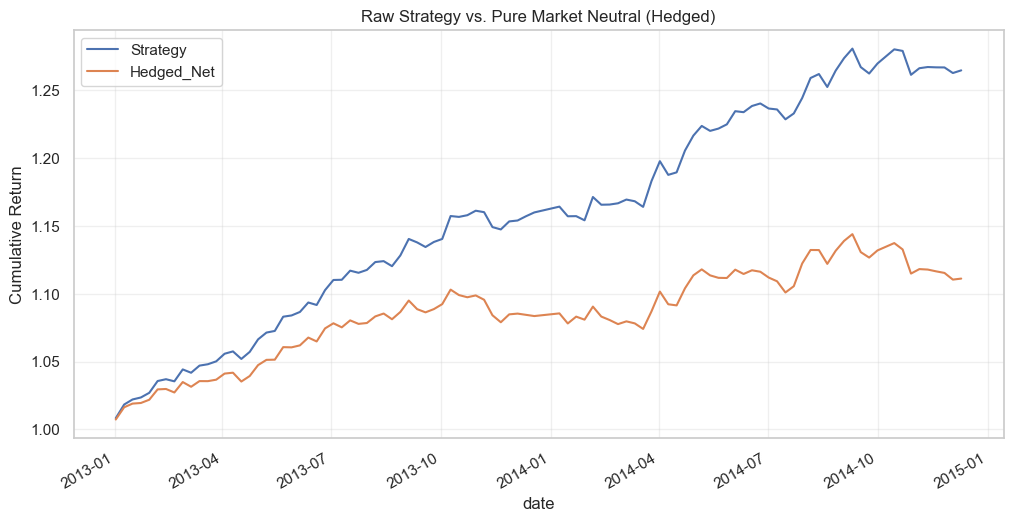

In [15]:
# CELL 10_v3: PURE MARKET NEUTRAL BACKTEST (CORRECTED)
import polars as pl
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# CONFIG
INPUT_FILE = "data_features_final.parquet"
TARGET_COL = "Target_Return_5D_Fwd"
SPLIT_DATE = "2013-01-01" 
COST_BPS = 0.0005 
HEDGE_LOOKBACK = 26 

def run_hedged_backtest():
    print("="*60)
    print("STEP 10: PURE MARKET NEUTRAL BACKTEST (TYPE-SAFE)")
    print("="*60)
    
    # 1. Load Data
    print("[1/5] Loading Data...")
    df = pl.read_parquet(INPUT_FILE)
    
    # --- TYPE SAFETY FIX ---
    # We specifically target the columns that caused the crash.
    # We replace commas if they exist, then cast to Float.
    print("      Enforcing Schema on Macro Columns...")
    
    macro_cols = ["USGG3M_PX_LAST", "SPX_PX_VOLUME", "SPX_CHG_PCT_1D", "VIX_CHG_PCT_1D", "USGG3M_CHG_PCT_1D"]
    
    # Check if these columns exist in the file before trying to fix them
    existing_macro = [c for c in macro_cols if c in df.columns]
    
    if existing_macro:
        df = df.with_columns([
            pl.col(c)
            .cast(pl.Utf8, strict=False) # Ensure it's string first
            .str.replace(",", "")        # Remove commas "1,000" -> "1000"
            .cast(pl.Float64, strict=False) # Convert to Float
            .fill_null(0.0)              # Handle any remaining NaNs safely
            for c in existing_macro
        ])
    
    # 2. Filter & Split
    df = df.filter(pl.col("Close") > 5.0)
    split_dt = pl.lit(SPLIT_DATE).str.strptime(pl.Date, "%Y-%m-%d")
    
    train_pl = df.filter(pl.col("date") < split_dt)
    
    # Purge Leakage
    train_pl = train_pl.with_columns(
        pl.col("date").rank(method="ordinal", descending=True).over("ticker").alias("rev_rank")
    ).filter(pl.col("rev_rank") > 5).drop("rev_rank")

    test_pl = df.filter(pl.col("date") >= split_dt)
    
    # Identify Features (excluding metadata)
    ignore_cols = ["date", "ticker", TARGET_COL, "Next_Day_Return", "VIX_PX_LAST", "SPX_PX_LAST", "VIX_Numeric"]
    feature_cols = [c for c in df.columns if c not in ignore_cols]
    
    # 3. Train
    print("[3/5] Training Model...")
    # Now that types are fixed, we can just convert to pandas directly
    X_train = train_pl.select(feature_cols).to_pandas()
    y_train = train_pl.select(TARGET_COL).to_pandas().values.ravel()
    
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # 4. Simulation
    print("[4/5] Running Simulation with Dynamic Hedging...")
    
    # Prepare Test Data
    X_test = test_pl.select(feature_cols).to_pandas()
    test_df = test_pl.select(["date", "ticker", TARGET_COL, "SPX_PX_LAST"]).to_pandas()
    
    # Ensure SPX is numeric for calculations
    test_df["SPX_PX_LAST"] = pd.to_numeric(test_df["SPX_PX_LAST"], errors='coerce')
    
    test_df["Alpha_Score"] = model.predict(X_test)
    
    # Weekly Sampling
    test_df["date"] = pd.to_datetime(test_df["date"])
    test_df["weekday"] = test_df["date"].dt.weekday
    weekly_df = test_df[test_df["weekday"] == 2].copy() # Wednesdays
    
    # 4a. Raw Strategy
    weekly_df["Rank"] = weekly_df.groupby("date")["Alpha_Score"].transform(
        lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
    )
    
    longs = weekly_df[weekly_df["Rank"] == 9].groupby("date")[TARGET_COL].mean()
    shorts = weekly_df[weekly_df["Rank"] == 0].groupby("date")[TARGET_COL].mean()
    raw_strategy = (longs - shorts) / 2
    
    # 4b. Market Returns
    spx_prices = weekly_df.groupby("date")["SPX_PX_LAST"].first().sort_index()
    spx_fwd_ret = spx_prices.shift(-1) / spx_prices - 1
    
    perf_df = pd.DataFrame({
        "Strategy": raw_strategy,
        "SPX": spx_fwd_ret
    }).dropna()
    
    # 4c. Hedging Loop
    hedged_returns = []
    betas = []
    
    print(f"      Hedging with {HEDGE_LOOKBACK}-week rolling lookback...")
    
    for i in range(len(perf_df)):
        if i < HEDGE_LOOKBACK:
            hedged_returns.append(perf_df["Strategy"].iloc[i])
            betas.append(0.0)
            continue
            
        window = perf_df.iloc[i-HEDGE_LOOKBACK : i]
        
        # Calculate Beta
        cov = window["Strategy"].cov(window["SPX"])
        var = window["SPX"].var()
        rolling_beta = cov / var if var > 1e-8 else 0.0
        rolling_beta = np.clip(rolling_beta, -0.5, 0.5) 
        
        # Hedge
        current_strat = perf_df["Strategy"].iloc[i]
        current_spx   = perf_df["SPX"].iloc[i]
        net_ret = current_strat - (rolling_beta * current_spx)
        
        hedged_returns.append(net_ret)
        betas.append(rolling_beta)
        
    perf_df["Hedged_Gross"] = hedged_returns
    perf_df["Hedge_Beta"] = betas
    perf_df["Hedged_Net"] = perf_df["Hedged_Gross"] - (2 * COST_BPS)
    
    # 5. Results
    print("\n" + "="*40)
    print("📊 PURE ALPHA RESULTS (Market Neutral)")
    print("=" * 40)
    
    ann_mean = perf_df["Hedged_Net"].mean() * 52
    ann_std  = perf_df["Hedged_Net"].std() * np.sqrt(52)
    sharpe   = ann_mean / ann_std
    avg_beta = perf_df["Hedge_Beta"].mean()
    
    print(f"Avg Hedge Beta:       {avg_beta:.4f} (Amount of SPX risk removed)")
    print(f"Annualized Return:    {ann_mean:.2%}")
    print(f"Annualized Sharpe:    {sharpe:.4f}")
    
    # Visuals
    plt.figure(figsize=(12, 6))
    (1 + perf_df[["Strategy", "Hedged_Net"]]).cumprod().plot(ax=plt.gca())
    plt.title("Raw Strategy vs. Pure Market Neutral (Hedged)")
    plt.ylabel("Cumulative Return")
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_hedged_backtest()

In [1]:
print("done")

done
